In [1]:
# Import necessary libraries
from sage.all import *

# Variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define the effective time with a phase shift
theta = var('theta')
t_eff = t + I*theta  # Complex time with quantum phase

# Define quantum dissipation operator Delta_Q (simplified model for now)
def Delta_Q(velocity_field):
    return laplacian(velocity_field)

# Regularized Navier-Stokes equations for each velocity component
nu = var('nu')  # Viscosity
epsilon = var('epsilon')  # Regularization parameter
quantum_regularization_term = epsilon * Delta_Q(u)

# Time-stepping equations
NS_u = diff(u, t_eff) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) + diff(p, x) - nu * laplacian(u) - quantum_regularization_term
NS_v = diff(v, t_eff) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) + diff(p, y) - nu * laplacian(v) - quantum_regularization_term
NS_w = diff(w, t_eff) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) + diff(p, z) - nu * laplacian(w) - quantum_regularization_term

# Print the system of equations
(NS_u, NS_v, NS_w)

NameError: name 'laplacian' is not defined

In [2]:
# Set up initial conditions (for example, a vortex or other flow field)
initial_conditions_u = x * y * exp(-x^2 - y^2)
initial_conditions_v = -x * z * exp(-x^2 - z^2)
initial_conditions_w = y * z * exp(-y^2 - z^2)

# Time-stepping parameters
dt = 0.01  # Time step size
t_final = 10  # Total simulation time

# Initialize fields
u_field = initial_conditions_u
v_field = initial_conditions_v
w_field = initial_conditions_w

# Time-stepping loop
for t_step in srange(0, t_final, dt):
    u_field = u_field + dt * NS_u.substitute(t=t_step)
    v_field = v_field + dt * NS_v.substitute(t=t_step)
    w_field = w_field + dt * NS_w.substitute(t=t_step)

# Plot the results for u, v, w after time-stepping
plot3d(u_field, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

NameError: name 'NS_u' is not defined

In [3]:
# Define quantum dissipation operator Delta_Q (Laplacian using divergence of gradient)
def Delta_Q(velocity_field):
    return divergence(gradient(velocity_field))

In [4]:
# Import necessary libraries
from sage.all import *

# Variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define the effective time with a phase shift
theta = var('theta')
t_eff = t + I*theta  # Complex time with quantum phase

# Define quantum dissipation operator Delta_Q (Laplacian using divergence of gradient)
def Delta_Q(velocity_field):
    return divergence(gradient(velocity_field))

# Regularized Navier-Stokes equations for each velocity component
nu = var('nu')  # Viscosity
epsilon = var('epsilon')  # Regularization parameter

# Quantum regularization term
quantum_regularization_term = epsilon * Delta_Q(u)

# Time-stepping equations
NS_u = diff(u, t_eff) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) + diff(p, x) - nu * Delta_Q(u) - quantum_regularization_term
NS_v = diff(v, t_eff) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) + diff(p, y) - nu * Delta_Q(v) - quantum_regularization_term
NS_w = diff(w, t_eff) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) + diff(p, z) - nu * Delta_Q(w) - quantum_regularization_term

# Set up initial conditions (for example, a vortex or other flow field)
initial_conditions_u = x * y * exp(-x^2 - y^2)
initial_conditions_v = -x * z * exp(-x^2 - z^2)
initial_conditions_w = y * z * exp(-y^2 - z^2)

# Time-stepping parameters
dt = 0.01  # Time step size
t_final = 10  # Total simulation time

# Initialize fields
u_field = initial_conditions_u
v_field = initial_conditions_v
w_field = initial_conditions_w

# Time-stepping loop
for t_step in srange(0, t_final, dt):
    u_field = u_field + dt * NS_u.substitute(t=t_step)
    v_field = v_field + dt * NS_v.substitute(t=t_step)
    w_field = w_field + dt * NS_w.substitute(t=t_step)

# Plot the results for u, v, w after time-stepping
plot3d(u_field, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

NameError: name 'divergence' is not defined

In [5]:
# Import necessary libraries
from sage.all import *

# Variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define the effective time with a phase shift
theta = var('theta')
t_eff = t + I * theta  # Complex time with quantum phase

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, x), diff(field, y), diff(field, z)])

def divergence(vector_field):
    return diff(vector_field[0], x) + diff(vector_field[1], y) + diff(vector_field[2], z)

# Define velocity field as a vector
velocity_field = vector([u, v, w])

# Quantum dissipation operator Delta_Q (Laplacian as divergence of gradient)
def Delta_Q(velocity_field):
    return vector([divergence(gradient(velocity_field[i])) for i in range(3)])

# Regularized Navier-Stokes equations for each velocity component
nu = var('nu')  # Viscosity
epsilon = var('epsilon')  # Regularization parameter

# Quantum regularization term for each velocity component
quantum_regularization_term = epsilon * Delta_Q(velocity_field)

# Time-stepping equations
NS_u = diff(u, t_eff) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) + diff(p, x) - nu * divergence(gradient(u)) - quantum_regularization_term[0]
NS_v = diff(v, t_eff) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) + diff(p, y) - nu * divergence(gradient(v)) - quantum_regularization_term[1]
NS_w = diff(w, t_eff) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) + diff(p, z) - nu * divergence(gradient(w)) - quantum_regularization_term[2]

# Set up initial conditions (for example, a vortex or other flow field)
initial_conditions_u = x * y * exp(-x^2 - y^2)
initial_conditions_v = -x * z * exp(-x^2 - z^2)
initial_conditions_w = y * z * exp(-y^2 - z^2)

# Time-stepping parameters
dt = 0.01  # Time step size
t_final = 10  # Total simulation time

# Initialize fields
u_field = initial_conditions_u
v_field = initial_conditions_v
w_field = initial_conditions_w

# Time-stepping loop
for t_step in srange(0, t_final, dt):
    u_field = u_field + dt * NS_u.substitute(t=t_step)
    v_field = v_field + dt * NS_v.substitute(t=t_step)
    w_field = w_field + dt * NS_w.substitute(t=t_step)

# Plot the results for u, v, w after time-stepping
plot3d(u_field, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

TypeError: argument symb must be a symbol

In [6]:
# Import necessary libraries
from sage.all import *

# Variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define the effective time with a phase shift
theta = var('theta')
t_eff = t + I * theta  # Complex time with quantum phase

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, x), diff(field, y), diff(field, z)])

def divergence(vector_field):
    return diff(vector_field[0], x) + diff(vector_field[1], y) + diff(vector_field[2], z)

# Define velocity field as a vector
velocity_field = vector([u, v, w])

# Quantum dissipation operator Delta_Q (Laplacian as divergence of gradient)
def Delta_Q(velocity_field):
    return vector([divergence(gradient(velocity_field[i])) for i in range(3)])

# Regularized Navier-Stokes equations for each velocity component
nu = var('nu')  # Viscosity
epsilon = var('epsilon')  # Regularization parameter

# Quantum regularization term for each velocity component
quantum_regularization_term = epsilon * Delta_Q(velocity_field)

# Time-stepping equations (differentiate only with respect to real part of t)
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) + diff(p, x) - nu * divergence(gradient(u)) - quantum_regularization_term[0]
NS_v = diff(v, t) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) + diff(p, y) - nu * divergence(gradient(v)) - quantum_regularization_term[1]
NS_w = diff(w, t) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) + diff(p, z) - nu * divergence(gradient(w)) - quantum_regularization_term[2]

# Set up initial conditions (for example, a vortex or other flow field)
initial_conditions_u = x * y * exp(-x^2 - y^2)
initial_conditions_v = -x * z * exp(-x^2 - z^2)
initial_conditions_w = y * z * exp(-y^2 - z^2)

# Time-stepping parameters
dt = 0.01  # Time step size
t_final = 10  # Total simulation time

# Initialize fields
u_field = initial_conditions_u
v_field = initial_conditions_v
w_field = initial_conditions_w

# Time-stepping loop
for t_step in srange(0, t_final, dt):
    u_field = u_field + dt * NS_u.substitute(t=t_step)
    v_field = v_field + dt * NS_v.substitute(t=t_step)
    w_field = w_field + dt * NS_w.substitute(t=t_step)

# Plot the results for u, v, w after time-stepping
plot3d(u_field, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

ValueError: Variable 'epsilon' not found in ['x', 'y']

In [7]:
# Import necessary libraries
from sage.all import *

# Variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon = var('epsilon')  # Regularization parameter

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define the effective time with a phase shift
theta = var('theta')
t_eff = t + I * theta  # Complex time with quantum phase

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, x), diff(field, y), diff(field, z)])

def divergence(vector_field):
    return diff(vector_field[0], x) + diff(vector_field[1], y) + diff(vector_field[2], z)

# Define velocity field as a vector
velocity_field = vector([u, v, w])

# Quantum dissipation operator Delta_Q (Laplacian as divergence of gradient)
def Delta_Q(velocity_field):
    return vector([divergence(gradient(velocity_field[i])) for i in range(3)])

# Regularized Navier-Stokes equations for each velocity component
nu = var('nu')  # Viscosity

# Quantum regularization term for each velocity component
quantum_regularization_term = epsilon * Delta_Q(velocity_field)

# Time-stepping equations (differentiate only with respect to real part of t)
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) + diff(p, x) - nu * divergence(gradient(u)) - quantum_regularization_term[0]
NS_v = diff(v, t) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) + diff(p, y) - nu * divergence(gradient(v)) - quantum_regularization_term[1]
NS_w = diff(w, t) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) + diff(p, z) - nu * divergence(gradient(w)) - quantum_regularization_term[2]

# Set up initial conditions (for example, a vortex or other flow field)
initial_conditions_u = x * y * exp(-x^2 - y^2)
initial_conditions_v = -x * z * exp(-x^2 - z^2)
initial_conditions_w = y * z * exp(-y^2 - z^2)

# Time-stepping parameters
dt = 0.01  # Time step size
t_final = 10  # Total simulation time

# Initialize fields
u_field = initial_conditions_u
v_field = initial_conditions_v
w_field = initial_conditions_w

# Time-stepping loop
for t_step in srange(0, t_final, dt):
    u_field = u_field + dt * NS_u.substitute(t=t_step)
    v_field = v_field + dt * NS_v.substitute(t=t_step)
    w_field = w_field + dt * NS_w.substitute(t=t_step)

# Plot the results for u, v, w after time-stepping
# Add epsilon explicitly in the fast callable function
plot3d(u_field.substitute(epsilon=1), (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

ValueError: Variable 'nu' not found in ['x', 'y']

In [8]:
# Import necessary libraries
from sage.all import *

# Variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon = var('epsilon')  # Regularization parameter
nu = var('nu')  # Viscosity

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define the effective time with a phase shift
theta = var('theta')
t_eff = t + I * theta  # Complex time with quantum phase

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, x), diff(field, y), diff(field, z)])

def divergence(vector_field):
    return diff(vector_field[0], x) + diff(vector_field[1], y) + diff(vector_field[2], z)

# Define velocity field as a vector
velocity_field = vector([u, v, w])

# Quantum dissipation operator Delta_Q (Laplacian as divergence of gradient)
def Delta_Q(velocity_field):
    return vector([divergence(gradient(velocity_field[i])) for i in range(3)])

# Regularized Navier-Stokes equations for each velocity component
# Quantum regularization term for each velocity component
quantum_regularization_term = epsilon * Delta_Q(velocity_field)

# Time-stepping equations (differentiate only with respect to real part of t)
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) + diff(p, x) - nu * divergence(gradient(u)) - quantum_regularization_term[0]
NS_v = diff(v, t) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) + diff(p, y) - nu * divergence(gradient(v)) - quantum_regularization_term[1]
NS_w = diff(w, t) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) + diff(p, z) - nu * divergence(gradient(w)) - quantum_regularization_term[2]

# Set up initial conditions (for example, a vortex or other flow field)
initial_conditions_u = x * y * exp(-x^2 - y^2)
initial_conditions_v = -x * z * exp(-x^2 - z^2)
initial_conditions_w = y * z * exp(-y^2 - z^2)

# Time-stepping parameters
dt = 0.01  # Time step size
t_final = 10  # Total simulation time

# Initialize fields
u_field = initial_conditions_u
v_field = initial_conditions_v
w_field = initial_conditions_w

# Time-stepping loop
for t_step in srange(0, t_final, dt):
    u_field = u_field + dt * NS_u.substitute(t=t_step)
    v_field = v_field + dt * NS_v.substitute(t=t_step)
    w_field = w_field + dt * NS_w.substitute(t=t_step)

# Create a substitution dictionary for plotting variables
substitutions = {epsilon: 1, nu: 1}  # You can modify these values as needed

# Plot the results for u, v, w after time-stepping, substitute epsilon and nu values
plot3d(u_field.substitute(substitutions), (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

ValueError: Variable 'z' not found in ['x', 'y']

In [9]:
# Import necessary libraries
from sage.all import *

# Variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon = var('epsilon')  # Regularization parameter
nu = var('nu')  # Viscosity

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define the effective time with a phase shift
theta = var('theta')
t_eff = t + I * theta  # Complex time with quantum phase

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, x), diff(field, y), diff(field, z)])

def divergence(vector_field):
    return diff(vector_field[0], x) + diff(vector_field[1], y) + diff(vector_field[2], z)

# Quantum regularization term
def Delta_Q(velocity_field):
    return divergence(gradient(velocity_field))

# Time-stepping equations for u, v, w
quantum_regularization_term = epsilon * Delta_Q(u)

# Substitute a specific value for epsilon and nu to avoid issues
epsilon_value = 1  # You can adjust this as needed
nu_value = 1

# Substitute in the regularization term and Navier-Stokes equations
u_substituted = u.substitute(epsilon=epsilon_value, nu=nu_value)
NS_u = diff(u_substituted, t_eff) + u_substituted * diff(u_substituted, x) - nu_value * Delta_Q(u_substituted)

# Plot u after substituting the variables explicitly
plot3d(NS_u.substitute(epsilon=epsilon_value), (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

TypeError: argument symb must be a symbol

In [10]:
# Import necessary libraries
from sage.all import *

# Variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon = var('epsilon')  # Regularization parameter
nu = var('nu')  # Viscosity

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define the effective time with a phase shift
theta = var('theta')
t_eff = t + I * theta  # Complex time with quantum phase

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, x), diff(field, y), diff(field, z)])

def divergence(vector_field):
    return diff(vector_field[0], x) + diff(vector_field[1], y) + diff(vector_field[2], z)

# Quantum regularization term
def Delta_Q(velocity_field):
    return divergence(gradient(velocity_field))

# Time-stepping equations for u, v, w
quantum_regularization_term = epsilon * Delta_Q(u)

# Time evolution without complex time (just use real part t for differentiation)
NS_u = diff(u, t) + u * diff(u, x) - nu * Delta_Q(u)

# Substitute specific values for epsilon and nu to avoid issues
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization term and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value)

# Now plot the result for u after substituting variables explicitly
plot3d(NS_u_substituted, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

ValueError: Variable 'z' not found in ['x', 'y']

In [11]:
# Import necessary libraries
from sage.all import *

# Variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon = var('epsilon')  # Regularization parameter
nu = var('nu')  # Viscosity

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define the effective time with a phase shift
theta = var('theta')
t_eff = t + I * theta  # Complex time with quantum phase

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, x), diff(field, y), diff(field, z)])

def divergence(vector_field):
    return diff(vector_field[0], x) + diff(vector_field[1], y) + diff(vector_field[2], z)

# Quantum regularization term
def Delta_Q(velocity_field):
    return divergence(gradient(velocity_field))

# Time-stepping equations for u, v, w
quantum_regularization_term = epsilon * Delta_Q(u)

# Time evolution without complex time (just use real part t for differentiation)
NS_u = diff(u, t) + u * diff(u, x) - nu * Delta_Q(u)

# Substitute specific values for epsilon and nu to avoid issues
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization term and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value)

# Create a callable symbolic expression for plotting with fast_callable
# This resolves the issue by explicitly defining the variables
NS_u_callable = fast_callable(NS_u_substituted, vars=[x, y, z], domain=RR)

# Now plot the result for u after substituting variables explicitly
plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

ValueError: Variable 't' not found in ['x', 'y', 'z']

In [12]:
# Import necessary libraries
from sage.all import *

# Variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon = var('epsilon')  # Regularization parameter
nu = var('nu')  # Viscosity

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define the effective time with a phase shift
theta = var('theta')
t_eff = t + I * theta  # Complex time with quantum phase

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, x), diff(field, y), diff(field, z)])

def divergence(vector_field):
    return diff(vector_field[0], x) + diff(vector_field[1], y) + diff(vector_field[2], z)

# Quantum regularization term
def Delta_Q(velocity_field):
    return divergence(gradient(velocity_field))

# Time-stepping equations for u, v, w
quantum_regularization_term = epsilon * Delta_Q(u)

# Time evolution without complex time (just use real part t for differentiation)
NS_u = diff(u, t) + u * diff(u, x) - nu * Delta_Q(u)

# Substitute specific values for epsilon and nu to avoid issues
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization term and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value)

# Create a callable symbolic expression for plotting with fast_callable
# Include time `t` in the list of variables
NS_u_callable = fast_callable(NS_u_substituted, vars=[x, y, z, t], domain=RR)

# Now plot the result for u after substituting variables explicitly
plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

NotImplementedError: derivative

In [13]:
# Import necessary libraries
from sage.all import *

# Variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon = var('epsilon')  # Regularization parameter
nu = var('nu')  # Viscosity

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, x), diff(field, y), diff(field, z)])

def divergence(vector_field):
    return diff(vector_field[0], x) + diff(vector_field[1], y) + diff(vector_field[2], z)

# Quantum regularization term
def Delta_Q(velocity_field):
    return divergence(gradient(velocity_field))

# Time-stepping equations for u
quantum_regularization_term = epsilon * Delta_Q(u)

# Time evolution without complex time (just use real part t for differentiation)
NS_u = diff(u, t) + u * diff(u, x) - nu * Delta_Q(u)

# Substitute specific values for epsilon and nu to avoid issues
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization term and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value)

# Evaluate derivatives explicitly to avoid NotImplementedError
NS_u_evaluated = NS_u_substituted.simplify_full()

# Create a callable symbolic expression for plotting with fast_callable
# Include time `t` in the list of variables
NS_u_callable = fast_callable(NS_u_evaluated, vars=[x, y, z, t], domain=RR)

# Now plot the result for u after substituting variables explicitly
plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

NotImplementedError: derivative

In [14]:
# Import necessary libraries
from sage.all import *

# Variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon = var('epsilon')  # Regularization parameter
nu = var('nu')  # Viscosity

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, x), diff(field, y), diff(field, z)])

def divergence(vector_field):
    return diff(vector_field[0], x) + diff(vector_field[1], y) + diff(vector_field[2], z)

# Quantum regularization term
def Delta_Q(velocity_field):
    return divergence(gradient(velocity_field))

# Time-stepping equations for u
quantum_regularization_term = epsilon * Delta_Q(u)

# Time evolution without complex time (just use real part t for differentiation)
NS_u = diff(u, t) + u * diff(u, x) - nu * Delta_Q(u)

# Substitute specific values for epsilon and nu to avoid issues
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization term and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value)

# Evaluate derivatives explicitly to avoid NotImplementedError
NS_u_evaluated = NS_u_substituted.simplify_full()

# Now plot the result for u after substituting variables explicitly
plot3d(NS_u_evaluated, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

ValueError: Variable 'z' not found in ['x', 'y']

In [15]:
# Import necessary libraries
from sage.all import *

# Variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon = var('epsilon')  # Regularization parameter
nu = var('nu')  # Viscosity

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, x), diff(field, y), diff(field, z)])

def divergence(vector_field):
    return diff(vector_field[0], x) + diff(vector_field[1], y) + diff(vector_field[2], z)

# Quantum regularization term
def Delta_Q(velocity_field):
    return divergence(gradient(velocity_field))

# Time-stepping equations for u
quantum_regularization_term = epsilon * Delta_Q(u)

# Time evolution without complex time (just use real part t for differentiation)
NS_u = diff(u, t) + u * diff(u, x) - nu * Delta_Q(u)

# Substitute specific values for epsilon and nu to avoid issues
​⬤

SyntaxError: invalid non-printable character U+200B (2645533526.py, line 36)

In [16]:
# Import necessary libraries
from sage.all import *

# Variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon = var('epsilon')  # Regularization parameter
nu = var('nu')  # Viscosity

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, x), diff(field, y), diff(field, z)])

def divergence(vector_field):
    return diff(vector_field[0], x) + diff(vector_field[1], y) + diff(vector_field[2], z)

# Quantum regularization term
def Delta_Q(velocity_field):
    return divergence(gradient(velocity_field))

# Time-stepping equations for u
quantum_regularization_term = epsilon * Delta_Q(u)

# Time evolution without complex time (just use real part t for differentiation)
NS_u = diff(u, t) + u * diff(u, x) - nu * Delta_Q(u)

# Substitute specific values for epsilon and nu to avoid issues
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization term and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value)

# Simplify the equation fully before plotting
NS_u_evaluated = NS_u_substituted.simplify_full()

# Plot the result for u after substituting variables explicitly
plot3d(NS_u_evaluated, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

ValueError: Variable 'z' not found in ['x', 'y']

In [17]:
# Import necessary libraries
from sage.all import *

# Variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon = var('epsilon')  # Regularization parameter
nu = var('nu')  # Viscosity

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, x), diff(field, y), diff(field, z)])

def divergence(vector_field):
    return diff(vector_field[0], x) + diff(vector_field[1], y) + diff(vector_field[2], z)

# Quantum regularization term
def Delta_Q(velocity_field):
    return divergence(gradient(velocity_field))

# Time-stepping equations for u
quantum_regularization_term = epsilon * Delta_Q(u)

# Time evolution without complex time (just use real part t for differentiation)
NS_u = diff(u, t) + u * diff(u, x) - nu * Delta_Q(u)

# Substitute specific values for epsilon and nu to avoid issues
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization term and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value)

# Simplify the equation fully before plotting
NS_u_evaluated = NS_u_substituted.simplify_full()

# Check for dependence on variables
dependent_vars = NS_u_evaluated.variables()
print("Dependent variables: ", dependent_vars)

# Adjust plot command based on variable dependence
if z in dependent_vars:
    plot3d(NS_u_evaluated, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()
else:
    # Plot without z, as it may not be part of the simplified equation
    plot3d(NS_u_evaluated, (x, -3, 3), (y, -3, 3), color="blue").show()

Dependent variables:  (t, x, y, z)


ValueError: Variable 'z' not found in ['x', 'y']

In [18]:
# Import necessary libraries
from sage.all import *

# Variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon = var('epsilon')  # Regularization parameter
nu = var('nu')  # Viscosity

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, x), diff(field, y), diff(field, z)])

def divergence(vector_field):
    return diff(vector_field[0], x) + diff(vector_field[1], y) + diff(vector_field[2], z)

# Quantum regularization term
def Delta_Q(velocity_field):
    return divergence(gradient(velocity_field))

# Time-stepping equations for u
quantum_regularization_term = epsilon * Delta_Q(u)

# Time evolution without complex time (just use real part t for differentiation)
NS_u = diff(u, t) + u * diff(u, x) - nu * Delta_Q(u)

# Substitute specific values for epsilon and nu to avoid issues
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization term and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value)

# Simplify the equation fully before plotting
NS_u_evaluated = NS_u_substituted.simplify_full()

# Check for dependence on variables
dependent_vars = NS_u_evaluated.variables()
print("Dependent variables: ", dependent_vars)

# Ensure that all variables are explicitly passed for fast_callable
NS_u_callable = fast_callable(NS_u_evaluated, vars=[x, y, z, t], domain=RR)

# Plotting with all three spatial variables and specifying color explicitly
plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

Dependent variables:  (t, x, y, z)


NotImplementedError: derivative

In [19]:
# Import necessary libraries
from sage.all import *

# Variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon = var('epsilon')  # Regularization parameter
nu = var('nu')  # Viscosity

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, x), diff(field, y), diff(field, z)])

def divergence(vector_field):
    return diff(vector_field[0], x) + diff(vector_field[1], y) + diff(vector_field[2], z)

# Quantum regularization term
def Delta_Q(velocity_field):
    return divergence(gradient(velocity_field))

# Time-stepping equations for u
quantum_regularization_term = epsilon * Delta_Q(u)

# Time evolution without complex time (just use real part t for differentiation)
NS_u = diff(u, t) + u * diff(u, x) - nu * Delta_Q(u)

# Substitute specific values for epsilon and nu to avoid issues
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization term and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value)

# Simplify the equation fully before plotting
NS_u_evaluated = NS_u_substituted.simplify_full()

# Precompute derivatives and explicitly resolve all derivatives
NS_u_computed = NS_u_evaluated.diff(t).simplify_full()

# Ensure that all variables are explicitly passed for fast_callable
NS_u_callable = fast_callable(NS_u_computed, vars=[x, y, z, t], domain=RR)

# Plotting with all three spatial variables and specifying color explicitly
plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

NotImplementedError: derivative

In [20]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon = var('epsilon')  # Regularization parameter
nu = var('nu')  # Viscosity

# Define velocity field components u, v, w in 3D
u = function('u')(x, y, z, t)
v = function('v')(x, y, z, t)
w = function('w')(x, y, z, t)

# Define pressure field p
p = function('p')(x, y, z, t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, x), diff(field, y), diff(field, z)])

def divergence(vector_field):
    return diff(vector_field[0], x) + diff(vector_field[1], y) + diff(vector_field[2], z)

# Quantum regularization term
def Delta_Q(velocity_field):
    return divergence(gradient(velocity_field))

# Time-stepping equations for u
quantum_regularization_term = epsilon * Delta_Q(u)

# Time evolution without complex time (just use real part t for differentiation)
NS_u = diff(u, t) + u * diff(u, x) - nu * Delta_Q(u)

# Substitute specific values for epsilon and nu to avoid issues
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization term and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value)

# Simplify the equation fully
NS_u_evaluated = NS_u_substituted.simplify_full()

# Compute derivatives explicitly to avoid `NotImplementedError`
NS_u_computed = NS_u_evaluated.differentiate(t).simplify_full()

# Ensure that all variables are explicitly passed for fast_callable
try:
    NS_u_callable = fast_callable(NS_u_computed, vars=[x, y, z, t], domain=RR)

    # Plotting with all three spatial variables and specifying color explicitly
    plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

except NotImplementedError as e:
    print("Error: Uncomputed derivatives found. Please ensure derivatives are precomputed.")
    print("Details:", str(e))

Error: Uncomputed derivatives found. Please ensure derivatives are precomputed.
Details: derivative


In [21]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon = var('epsilon')  # Regularization parameter
nu = var('nu')  # Viscosity

# Define explicit velocity field components u, v, w in 3D as simple functions
# Example: Trigonometric or polynomial functions
u = sin(x)*cos(y)*exp(-t)
v = cos(x)*sin(z)*exp(-t)
w = x*y*z*exp(-t)

# Define pressure field p as an explicit function
p = cos(x)*sin(y)*cos(z)*exp(-t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, x), diff(field, y), diff(field, z)])

def divergence(vector_field):
    return diff(vector_field[0], x) + diff(vector_field[1], y) + diff(vector_field[2], z)

# Quantum regularization term
def Delta_Q(velocity_field):
    return divergence(gradient(velocity_field))

# Time-stepping equation for u (Navier-Stokes with quantum regularization)
quantum_regularization_term = epsilon * Delta_Q(u)

# Time evolution without complex time (just use real part t for differentiation)
NS_u = diff(u, t) + u * diff(u, x) - nu * Delta_Q(u)

# Substitute specific values for epsilon and nu to avoid issues
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization term and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value)

# Simplify the equation fully
NS_u_evaluated = NS_u_substituted.simplify_full()

# Compute derivatives explicitly to avoid `NotImplementedError`
NS_u_computed = NS_u_evaluated.simplify_full()

# Ensure that all variables are explicitly passed for fast_callable
try:
    NS_u_callable = fast_callable(NS_u_computed, vars=[x, y, z, t], domain=RR)

    # Plotting with all three spatial variables and specifying color explicitly
    plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

except NotImplementedError as e:
    print("Error: Uncomputed derivatives found. Please ensure derivatives are precomputed.")
    print("Details:", str(e))

ValueError: 

In [22]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon, nu = var('epsilon nu')  # Regularization and viscosity parameters

# Define explicit velocity field components u, v, w in 3D as example functions
# You can replace these with any other smooth functions.
u = sin(x)*cos(y)*exp(-t)
v = cos(x)*sin(z)*exp(-t)
w = x*y*z*exp(-t)

# Define pressure field p as an example function
p = cos(x)*sin(y)*cos(z)*exp(-t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, var) for var in (x, y, z)])

def divergence(vector_field):
    return sum(diff(vector_field[i], var) for i, var in enumerate((x, y, z)))

# Quantum regularization term (Laplacian of the velocity field)
def Delta_Q(velocity_field):
    grad_field = gradient(velocity_field)
    return divergence(grad_field)

# Navier-Stokes equation with quantum regularization for u
quantum_regularization_term = epsilon * Delta_Q(u)

# Time evolution equation for u
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) - nu * Delta_Q(u)

# Substitute specific values for epsilon and nu
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization term and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value)

# Simplify the equation fully
NS_u_simplified = NS_u_substituted.simplify_full()

# Ensure that all derivatives are computed explicitly
NS_u_computed = NS_u_simplified.simplify_full()

# Plot the results (assuming u is dependent on x, y, z)
try:
    # Create a callable symbolic expression for plotting
    NS_u_callable = fast_callable(NS_u_computed, vars=[x, y, z, t], domain=RR)

    # Plotting with all three spatial variables and color
    plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

except NotImplementedError as e:
    print("Error: Uncomputed derivatives found. Please ensure derivatives are precomputed.")
    print("Details:", str(e))
except ValueError as e:
    print("ValueError encountered during plotting:", str(e))

ValueError encountered during plotting: 


In [23]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon, nu = var('epsilon nu')  # Regularization and viscosity parameters

# Define explicit velocity field components u, v, w in 3D as example functions
# You can replace these with any other smooth functions.
u = sin(x)*cos(y)*exp(-t)
v = cos(x)*sin(z)*exp(-t)
w = x*y*z*exp(-t)

# Define pressure field p as an example function
p = cos(x)*sin(y)*cos(z)*exp(-t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, var) for var in (x, y, z)])

def divergence(vector_field):
    return sum(diff(vector_field[i], var) for i, var in enumerate((x, y, z)))

# Quantum regularization term (Laplacian of the velocity field)
def Delta_Q(velocity_field):
    grad_field = gradient(velocity_field)
    return divergence(grad_field)

# Navier-Stokes equation with quantum regularization for u
quantum_regularization_term = epsilon * Delta_Q(u)

# Time evolution equation for u
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) - nu * Delta_Q(u)

# Substitute specific values for epsilon and nu
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization term and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value)

# Simplify the equation fully
NS_u_simplified = NS_u_substituted.simplify_full()

# Ensure that all derivatives are computed explicitly
NS_u_computed = NS_u_simplified.simplify_full()

# Attempt to prepare for plotting
try:
    # Create a callable symbolic expression for plotting
    NS_u_callable = fast_callable(NS_u_computed, vars=[x, y, z, t], domain=RR)
    
    # Print for debugging purposes
    print("Expression after computation and simplification:")
    print(NS_u_computed)

    # Plotting with all three spatial variables and color
    plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

except NotImplementedError as e:
    print("Error: Uncomputed derivatives found. Please ensure derivatives are precomputed.")
    print("Details:", str(e))
except ValueError as e:
    print("ValueError encountered during plotting:", str(e))
    print("Attempting to simplify the function for plotting...")

    # Try to simplify further and plot in 2D if necessary
    try:
        # Reduce the problem to two spatial variables if needed
        NS_u_callable_2D = fast_callable(NS_u_computed, vars=[x, y, t], domain=RR)
        plot3d(NS_u_callable_2D, (x, -3, 3), (y, -3, 3), color="blue").show()

    except Exception as e:
        print("Further error encountered during simplified 2D plotting:", str(e))

Expression after computation and simplification:
(cos(x)*cos(y)^2*sin(x) - cos(x)*sin(x)*sin(y)*sin(z) + cos(y)*e^t*sin(x))*e^(-2*t)
ValueError encountered during plotting: 
Attempting to simplify the function for plotting...
Further error encountered during simplified 2D plotting: Variable 'z' not found in ['x', 'y', 't']


In [24]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y = var('x y')  # Spatial variables (2D for simplicity)
epsilon, nu = var('epsilon nu')  # Regularization and viscosity parameters

# Define explicit velocity field components u, v in 2D as example functions
# You can replace these with any other smooth functions.
u = sin(x)*cos(y)*exp(-t)
v = cos(x)*sin(y)*exp(-t)

# Define pressure field p as an example function (2D)
p = cos(x)*sin(y)*exp(-t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, var) for var in (x, y)])

def divergence(vector_field):
    return sum(diff(vector_field[i], var) for i, var in enumerate((x, y)))

# Quantum regularization term (Laplacian of the velocity field)
def Delta_Q(velocity_field):
    grad_field = gradient(velocity_field)
    return divergence(grad_field)

# Navier-Stokes equation with quantum regularization for u
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) - nu * Delta_Q(u)

# Substitute specific values for epsilon and nu
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization term and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value)

# Simplify the equation fully
NS_u_simplified = NS_u_substituted.simplify_full()

# Plotting in 2D
try:
    # Create a callable symbolic expression for plotting
    NS_u_callable = fast_callable(NS_u_simplified, vars=[x, y, t], domain=RR)
    
    # Print for debugging purposes
    print("Expression after computation and simplification:")
    print(NS_u_simplified)

    # Plotting in 2D (x, y) for t = 0
    plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), color="blue").show()

except Exception as e:
    print("Error encountered during plotting:", str(e))

Expression after computation and simplification:
-(2*cos(x)*sin(x)*sin(y)^2 - cos(y)*e^t*sin(x) - cos(x)*sin(x))*e^(-2*t)


Graphics3d Object

In [25]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y = var('x y')  # Spatial variables (2D for simplicity)
epsilon, nu = var('epsilon nu')  # Regularization and viscosity parameters

# Define explicit velocity field components u, v in 2D as example functions
u = sin(x)*cos(y)*exp(-t)
v = cos(x)*sin(y)*exp(-t)

# Define pressure field p as an example function (2D)
p = cos(x)*sin(y)*exp(-t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, var) for var in (x, y)])

def divergence(vector_field):
    return sum(diff(vector_field[i], var) for i, var in enumerate((x, y)))

# Quantum regularization term (Laplacian of the velocity field)
def Delta_Q(velocity_field):
    grad_field = gradient(velocity_field)
    return divergence(grad_field)

# Navier-Stokes equation with quantum regularization for u
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) - nu * Delta_Q(u)

# Substitute specific values for epsilon and nu
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization term and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value)

# Simplify the equation fully
NS_u_simplified = NS_u_substituted.simplify_full()

# Set t = 0 for visualization
NS_u_at_t0 = NS_u_simplified.substitute(t=0).simplify_full()

# Plotting in 2D (at t = 0)
try:
    # Create a callable symbolic expression for plotting
    NS_u_callable = fast_callable(NS_u_at_t0, vars=[x, y], domain=RR)
    
    # Print for debugging purposes
    print("Expression after setting t=0 and simplifying:")
    print(NS_u_at_t0)

    # Plotting in 2D (x, y) for t = 0
    plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), color="blue").show()

except Exception as e:
    print("Error encountered during plotting:", str(e))

Expression after setting t=0 and simplifying:
-2*cos(x)*sin(x)*sin(y)^2 + cos(x)*sin(x) + cos(y)*sin(x)


Graphics3d Object

In [26]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon, nu = var('epsilon nu')  # Regularization and viscosity parameters

# Define explicit velocity field components u, v, w in 3D as example functions
# These can be replaced with any other smooth functions representing velocity fields.
u = sin(x)*cos(y)*exp(-t)
v = cos(x)*sin(z)*exp(-t)
w = x*y*z*exp(-t)

# Define pressure field p as an example function
p = cos(x)*sin(y)*cos(z)*exp(-t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, var) for var in (x, y, z)])

def divergence(vector_field):
    return sum(diff(vector_field[i], var) for i, var in enumerate((x, y, z)))

# Quantum regularization term (Laplacian of the velocity field)
def Delta_Q(velocity_field):
    grad_field = gradient(velocity_field)
    return divergence(grad_field)

# Navier-Stokes equations with quantum regularization for u, v, w
quantum_regularization_u = epsilon * Delta_Q(u)
quantum_regularization_v = epsilon * Delta_Q(v)
quantum_regularization_w = epsilon * Delta_Q(w)

# Time evolution equations for u, v, w
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) - nu * Delta_Q(u)
NS_v = diff(v, t) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) - nu * Delta_Q(v)
NS_w = diff(w, t) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) - nu * Delta_Q(w)

# Substitute specific values for epsilon and nu
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization terms and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_v_substituted = NS_v.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_w_substituted = NS_w.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()

# Combine the velocity components into a vector field
velocity_field = vector([NS_u_substituted, NS_v_substituted, NS_w_substituted])

# Simplify the system
NS_combined_simplified = velocity_field.simplify_full()

# Print the results for debugging and analysis
print("Simplified Navier-Stokes system for u, v, w with quantum regularization:")
print(NS_combined_simplified)

# Visualize the system over space and time
try:
    # Create callable symbolic expressions for plotting u, v, w components
    NS_u_callable = fast_callable(NS_u_substituted, vars=[x, y, z, t], domain=RR)
    NS_v_callable = fast_callable(NS_v_substituted, vars=[x, y, z, t], domain=RR)
    NS_w_callable = fast_callable(NS_w_substituted, vars=[x, y, z, t], domain=RR)

    # Plot the u, v, and w components individually in 3D for t = 0
    print("Plotting u(x, y, z, t=0):")
    plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

    print("Plotting v(x, y, z, t=0):")
    plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="red").show()

    print("Plotting w(x, y, z, t=0):")
    plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="green").show()

except NotImplementedError as e:
    print("Error: Uncomputed derivatives found. Please ensure derivatives are precomputed.")
    print("Details:", str(e))
except ValueError as e:
    print("ValueError encountered during plotting:", str(e))
    print("Attempting to simplify the function for plotting...")

    # Try to simplify further and plot in 2D if necessary
    try:
        # Reduce the problem to two spatial variables if needed for 2D plotting
        NS_u_callable_2D = fast_callable(NS_u_substituted, vars=[x, y, t], domain=RR)
        plot3d(NS_u_callable_2D, (x, -3, 3), (y, -3, 3), color="blue").show()

        NS_v_callable_2D = fast_callable(NS_v_substituted, vars=[x, y, t], domain=RR)
        plot3d(NS_v_callable_2D, (x, -3, 3), (y, -3, 3), color="red").show()

        NS_w_callable_2D = fast_callable(NS_w_substituted, vars=[x, y, t], domain=RR)
        plot3d(NS_w_callable_2D, (x, -3, 3), (y, -3, 3), color="green").show()

    except Exception as e:
        print("Further error encountered during simplified 2D plotting:", str(e))

Simplified Navier-Stokes system for u, v, w with quantum regularization:
((cos(x)*cos(y)^2*sin(x) - cos(x)*sin(x)*sin(y)*sin(z) + cos(y)*e^t*sin(x))*e^(-2*t), (x*y*z*cos(x)*cos(z) + ((cos(x)^2 - 1)*cos(y) + cos(x)*e^t)*sin(z))*e^(-2*t), (x*z*cos(x)*sin(z) + (x^2*y^2 - x*y*e^t + y*cos(y)*sin(x))*z)*e^(-2*t))
Plotting u(x, y, z, t=0):
ValueError encountered during plotting: 
Attempting to simplify the function for plotting...
Further error encountered during simplified 2D plotting: Variable 'z' not found in ['x', 'y', 't']


In [27]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon, nu = var('epsilon nu')  # Regularization and viscosity parameters

# Define explicit velocity field components u, v, w in 3D as example functions
u = sin(x)*cos(y)*exp(-t)
v = cos(x)*sin(z)*exp(-t)
w = x*y*z*exp(-t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, var) for var in (x, y, z)])

def divergence(vector_field):
    return sum(diff(vector_field[i], var) for i, var in enumerate((x, y, z)))

# Quantum regularization term (Laplacian of the velocity field)
def Delta_Q(velocity_field):
    grad_field = gradient(velocity_field)
    return divergence(grad_field)

# Navier-Stokes equations with quantum regularization for u, v, w
quantum_regularization_u = epsilon * Delta_Q(u)
quantum_regularization_v = epsilon * Delta_Q(v)
quantum_regularization_w = epsilon * Delta_Q(w)

# Time evolution equations for u, v, w
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) - nu * Delta_Q(u)
NS_v = diff(v, t) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) - nu * Delta_Q(v)
NS_w = diff(w, t) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) - nu * Delta_Q(w)

# Substitute specific values for epsilon and nu
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization terms and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_v_substituted = NS_v.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_w_substituted = NS_w.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()

# Combine the velocity components into a vector field
velocity_field = vector([NS_u_substituted, NS_v_substituted, NS_w_substituted])

# Simplify the system
NS_combined_simplified = velocity_field.simplify_full()

# Print the results for debugging and analysis
print("Simplified Navier-Stokes system for u, v, w with quantum regularization:")
print(NS_combined_simplified)

# Visualize the system over space and time for t=0
try:
    # Evaluate the velocity components at t=0 for simplicity
    NS_u_t0 = NS_u_substituted.substitute(t=0).simplify_full()
    NS_v_t0 = NS_v_substituted.substitute(t=0).simplify_full()
    NS_w_t0 = NS_w_substituted.substitute(t=0).simplify_full()

    # Create callable symbolic expressions for plotting u, v, w components at t=0
    NS_u_callable = fast_callable(NS_u_t0, vars=[x, y, z], domain=RR)
    NS_v_callable = fast_callable(NS_v_t0, vars=[x, y, z], domain=RR)
    NS_w_callable = fast_callable(NS_w_t0, vars=[x, y, z], domain=RR)

    # Plot the u, v, and w components individually in 3D for t = 0
    print("Plotting u(x, y, z, t=0):")
    plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()

    print("Plotting v(x, y, z, t=0):")
    plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="red").show()

    print("Plotting w(x, y, z, t=0):")
    plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="green").show()

except NotImplementedError as e:
    print("Error: Uncomputed derivatives found. Please ensure derivatives are precomputed.")
    print("Details:", str(e))
except ValueError as e:
    print("ValueError encountered during plotting:", str(e))
    print("Attempting to simplify the function for plotting...")

    # Try to simplify further and plot in 2D if necessary
    try:
        # Reduce the problem to two spatial variables if needed for 2D plotting
        NS_u_callable_2D = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        plot3d(NS_u_callable_2D, (x, -3, 3), (y, -3, 3), color="blue").show()

        NS_v_callable_2D = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        plot3d(NS_v_callable_2D, (x, -3, 3), (y, -3, 3), color="red").show()

        NS_w_callable_2D = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        plot3d(NS_w_callable_2D, (x, -3, 3), (y, -3, 3), color="green").show()

    except Exception as e:
        print("Further error encountered during simplified 2D plotting:", str(e))

Simplified Navier-Stokes system for u, v, w with quantum regularization:
((cos(x)*cos(y)^2*sin(x) - cos(x)*sin(x)*sin(y)*sin(z) + cos(y)*e^t*sin(x))*e^(-2*t), (x*y*z*cos(x)*cos(z) + ((cos(x)^2 - 1)*cos(y) + cos(x)*e^t)*sin(z))*e^(-2*t), (x*z*cos(x)*sin(z) + (x^2*y^2 - x*y*e^t + y*cos(y)*sin(x))*z)*e^(-2*t))
Plotting u(x, y, z, t=0):
ValueError encountered during plotting: 
Attempting to simplify the function for plotting...
Further error encountered during simplified 2D plotting: Variable 'z' not found in ['x', 'y']


In [28]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon, nu = var('epsilon nu')  # Regularization and viscosity parameters

# Define explicit velocity field components u, v, w in 3D as example functions
u = sin(x)*cos(y)*exp(-t)
v = cos(x)*sin(z)*exp(-t)
w = x*y*z*exp(-t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, var) for var in (x, y, z)])

def divergence(vector_field):
    return sum(diff(vector_field[i], var) for i, var in enumerate((x, y, z)))

# Quantum regularization term (Laplacian of the velocity field)
def Delta_Q(velocity_field):
    grad_field = gradient(velocity_field)
    return divergence(grad_field)

# Navier-Stokes equations with quantum regularization for u, v, w
quantum_regularization_u = epsilon * Delta_Q(u)
quantum_regularization_v = epsilon * Delta_Q(v)
quantum_regularization_w = epsilon * Delta_Q(w)

# Time evolution equations for u, v, w
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) - nu * Delta_Q(u)
NS_v = diff(v, t) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) - nu * Delta_Q(v)
NS_w = diff(w, t) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) - nu * Delta_Q(w)

# Substitute specific values for epsilon and nu
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization terms and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_v_substituted = NS_v.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_w_substituted = NS_w.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()

# Combine the velocity components into a vector field
velocity_field = vector([NS_u_substituted, NS_v_substituted, NS_w_substituted])

# Simplify the system
NS_combined_simplified = velocity_field.simplify_full()

# Print the results for debugging and analysis
print("Simplified Navier-Stokes system for u, v, w with quantum regularization:")
print(NS_combined_simplified)

# Visualize the system over space and time for t=0
try:
    # Evaluate the velocity components at t=0 for simplicity
    NS_u_t0 = NS_u_substituted.substitute(t=0).simplify_full()
    NS_v_t0 = NS_v_substituted.substitute(t=0).simplify_full()
    NS_w_t0 = NS_w_substituted.substitute(t=0).simplify_full()

    # Check if z is still a variable in the expressions
    dependent_vars_u = NS_u_t0.variables()
    dependent_vars_v = NS_v_t0.variables()
    dependent_vars_w = NS_w_t0.variables()

    print(f"Dependent variables for u: {dependent_vars_u}")
    print(f"Dependent variables for v: {dependent_vars_v}")
    print(f"Dependent variables for w: {dependent_vars_w}")

    # Plot u-component
    if z in dependent_vars_u:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y, z], domain=RR)
        print("Plotting u(x, y, z, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()
    else:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        print("Plotting u(x, y, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), color="blue").show()

    # Plot v-component
    if z in dependent_vars_v:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y, z], domain=RR)
        print("Plotting v(x, y, z, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="red").show()
    else:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        print("Plotting v(x, y, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), color="red").show()

    # Plot w-component
    if z in dependent_vars_w:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y, z], domain=RR)
        print("Plotting w(x, y, z, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="green").show()
    else:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        print("Plotting w(x, y, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), color="green").show()

except NotImplementedError as e:
    print("Error: Uncomputed derivatives found. Please ensure derivatives are precomputed.")
    print("Details:", str(e))
except ValueError as e:
    print("ValueError encountered during plotting:", str(e))
    print("Attempting to simplify the function for plotting...")

    # Try to simplify further and plot in 2D if necessary
    try:
        # Reduce the problem to two spatial variables if needed for 2D plotting
        NS_u_callable_2D = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        plot3d(NS_u_callable_2D, (x, -3, 3), (y, -3, 3), color="blue").show()

        NS_v_callable_2D = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        plot3d(NS_v_callable_2D, (x, -3, 3), (y, -3, 3), color="red").show()

        NS_w_callable_2D = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        plot3d(NS_w_callable_2D, (x, -3, 3), (y, -3, 3), color="green").show()

    except Exception as e:
        print("Further error encountered during simplified 2D plotting:", str(e))

Simplified Navier-Stokes system for u, v, w with quantum regularization:
((cos(x)*cos(y)^2*sin(x) - cos(x)*sin(x)*sin(y)*sin(z) + cos(y)*e^t*sin(x))*e^(-2*t), (x*y*z*cos(x)*cos(z) + ((cos(x)^2 - 1)*cos(y) + cos(x)*e^t)*sin(z))*e^(-2*t), (x*z*cos(x)*sin(z) + (x^2*y^2 - x*y*e^t + y*cos(y)*sin(x))*z)*e^(-2*t))
Dependent variables for u: (x, y, z)
Dependent variables for v: (x, y, z)
Dependent variables for w: (x, y, z)
Plotting u(x, y, z, t=0):
ValueError encountered during plotting: 
Attempting to simplify the function for plotting...
Further error encountered during simplified 2D plotting: Variable 'z' not found in ['x', 'y']


In [31]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon, nu = var('epsilon nu')  # Regularization and viscosity parameters

# Define explicit velocity field components u, v, w in 3D as example functions
u = sin(x)*cos(y)*exp(-t)
v = cos(x)*sin(z)*exp(-t)
w = x*y*z*exp(-t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, var) for var in (x, y, z)])

def divergence(vector_field):
    return sum(diff(vector_field[i], var) for i, var in enumerate((x, y, z)])

# Quantum regularization term (Laplacian of the velocity field)
def Delta_Q(velocity_field):
    grad_field = gradient(velocity_field)
    return divergence(grad_field)

# Navier-Stokes equations with quantum regularization for u, v, w
quantum_regularization_u = epsilon * Delta_Q(u)
quantum_regularization_v = epsilon * Delta_Q(v)
quantum_regularization_w = epsilon * Delta_Q(w)

# Time evolution equations for u, v, w
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) - nu * Delta_Q(u)
NS_v = diff(v, t) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) - nu * Delta_Q(v)
NS_w = diff(w, t) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) - nu * Delta_Q(w)

# Substitute specific values for epsilon and nu
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization terms and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_v_substituted = NS_v.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_w_substituted = NS_w.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()

# Combine the velocity components into a vector field
velocity_field = vector([NS_u_substituted, NS_v_substituted, NS_w_substituted])

# Simplify the system
NS_combined_simplified = velocity_field.simplify_full()

# Print the results for debugging and analysis
print("Simplified Navier-Stokes system for u, v, w with quantum regularization:")
print(NS_combined_simplified)

# Visualize the system over space and time for t=0
try:
    # Evaluate the velocity components at t=0 for simplicity
    NS_u_t0 = NS_u_substituted.substitute(t=0).simplify_full()
    NS_v_t0 = NS_v_substituted.substitute(t=0).simplify_full()
    NS_w_t0 = NS_w_substituted.substitute(t=0).simplify_full()

    # Check if z is still a variable in the expressions
    dependent_vars_u = NS_u_t0.variables()
    dependent_vars_v = NS_v_t0.variables()
    dependent_vars_w = NS_w_t0.variables()

    print(f"Dependent variables for u: {dependent_vars_u}")
    print(f"Dependent variables for v: {dependent_vars_v}")
    print(f"Dependent variables for w: {dependent_vars_w}")

    # Plot u-component
    if z in dependent_vars_u:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y, z], domain=RR)
        print("Plotting u(x, y, z, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()
    else:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        print("Plotting u(x, y, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), color="blue").show()

    # Plot v-component
    if z in dependent_vars_v:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y, z], domain=RR)
        print("Plotting v(x, y, z, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="red").show()
    else:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        print("Plotting v(x, y, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), color="red").show()

    # Plot w-component
    if z in dependent_vars_w:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y, z], domain=RR)
        print("Plotting w(x, y, z, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="green").show()
    else:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        print("Plotting w(x, y, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), color="green").show()

except NotImplementedError as e:
    print("Error: Uncomputed derivatives found. Please ensure derivatives are precomputed.")
    print("Details:", str(e))
except ValueError as e:
    print("ValueError encountered during plotting:", str(e))
    print("Attempting to simplify the function for plotting...")

    # Try to simplify further and plot in 2D if necessary
    try:
        # Reduce the problem to two spatial variables if needed for 2D plotting
        NS_u_callable_2D = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        plot3d(NS_u_callable_2D, (x, -3, 3), (y, -3, 3), color="blue").show()

        NS_v_callable_2D = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        plot3d(NS_v_callable_2D, (x, -3, 3), (y, -3, 3), color="red").show()

        NS_w_callable_2D = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        plot3d(NS_w_callable_2D, (x, -3, 3), (y, -3, 3), color="green").show()

    except Exception as e:
        print("Further error encountered during simplified 2D plotting:", str(e))

SyntaxError: closing parenthesis ']' does not match opening parenthesis '(' (2435712083.py, line 19)

In [32]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon, nu = var('epsilon nu')  # Regularization and viscosity parameters

# Define explicit velocity field components u, v, w in 3D as example functions
u = sin(x)*cos(y)*exp(-t)
v = cos(x)*sin(z)*exp(-t)
w = x*y*z*exp(-t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, var) for var in (x, y, z)])

def divergence(vector_field):
    return sum(diff(vector_field[i], var) for i, var in enumerate((x, y, z)])

# Quantum regularization term (Laplacian of the velocity field)
def Delta_Q(velocity_field):
    grad_field = gradient(velocity_field)
    return divergence(grad_field)

# Navier-Stokes equations with quantum regularization for u, v, w
quantum_regularization_u = epsilon * Delta_Q(u)
quantum_regularization_v = epsilon * Delta_Q(v)
quantum_regularization_w = epsilon * Delta_Q(w)

# Time evolution equations for u, v, w
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) - nu * Delta_Q(u)
NS_v = diff(v, t) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) - nu * Delta_Q(v)
NS_w = diff(w, t) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) - nu * Delta_Q(w)

# Substitute specific values for epsilon and nu
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization terms and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_v_substituted = NS_v.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_w_substituted = NS_w.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()

# Combine the velocity components into a vector field
velocity_field = vector([NS_u_substituted, NS_v_substituted, NS_w_substituted])

# Simplify the system
NS_combined_simplified = velocity_field.simplify_full()

# Print the results for debugging and analysis
print("Simplified Navier-Stokes system for u, v, w with quantum regularization:")
print(NS_combined_simplified)

# Visualize the system over space and time for t=0
try:
    # Evaluate the velocity components at t=0 for simplicity
    NS_u_t0 = NS_u_substituted.substitute(t=0).simplify_full()
    NS_v_t0 = NS_v_substituted.substitute(t=0).simplify_full()
    NS_w_t0 = NS_w_substituted.substitute(t=0).simplify_full()

    # Check if z is still a variable in the expressions
    dependent_vars_u = NS_u_t0.variables()
    dependent_vars_v = NS_v_t0.variables()
    dependent_vars_w = NS_w_t0.variables()

    print(f"Dependent variables for u: {dependent_vars_u}")
    print(f"Dependent variables for v: {dependent_vars_v}")
    print(f"Dependent variables for w: {dependent_vars_w}")

    # Plot u-component
    if z in dependent_vars_u:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y, z], domain=RR)
        print("Plotting u(x, y, z, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()
    else:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        print("Plotting u(x, y, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), color="blue").show()

    # Plot v-component
    if z in dependent_vars_v:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y, z], domain=RR)
        print("Plotting v(x, y, z, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="red").show()
    else:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        print("Plotting v(x, y, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), color="red").show()

    # Plot w-component
    if z in dependent_vars_w:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y, z], domain=RR)
        print("Plotting w(x, y, z, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="green").show()
    else:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        print("Plotting w(x, y, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), color="green").show()

except NotImplementedError as e:
    print("Error: Uncomputed derivatives found. Please ensure derivatives are precomputed.")
    print("Details:", str(e))
except ValueError as e:
    print("ValueError encountered during plotting:", str(e))
    print("Attempting to simplify the function for plotting...")

    # Try to simplify further and plot in 2D if necessary
    try:
        # Reduce the problem to two spatial variables if needed for 2D plotting
        NS_u_callable_2D = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        plot3d(NS_u_callable_2D, (x, -3, 3), (y, -3, 3), color="blue").show()

        NS_v_callable_2D = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        plot3d(NS_v_callable_2D, (x, -3, 3), (y, -3, 3), color="red").show()

        NS_w_callable_2D = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        plot3d(NS_w_callable_2D, (x, -3, 3), (y, -3, 3), color="green").show()

    except Exception as e:
        print("Further error encountered during simplified 2D plotting:", str(e))

SyntaxError: closing parenthesis ']' does not match opening parenthesis '(' (2435712083.py, line 19)

In [33]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon, nu = var('epsilon nu')  # Regularization and viscosity parameters

# Define explicit velocity field components u, v, w in 3D as example functions
u = sin(x)*cos(y)*exp(-t)
v = cos(x)*sin(z)*exp(-t)
w = x*y*z*exp(-t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, var) for var in (x, y, z)])

def divergence(vector_field):
    return sum(diff(vector_field[i], var) for i, var in enumerate((x, y, z)))

# Quantum regularization term (Laplacian of the velocity field)
def Delta_Q(velocity_field):
    grad_field = gradient(velocity_field)
    return divergence(grad_field)

# Navier-Stokes equations with quantum regularization for u, v, w
quantum_regularization_u = epsilon * Delta_Q(u)
quantum_regularization_v = epsilon * Delta_Q(v)
quantum_regularization_w = epsilon * Delta_Q(w)

# Time evolution equations for u, v, w
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) - nu * Delta_Q(u)
NS_v = diff(v, t) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) - nu * Delta_Q(v)
NS_w = diff(w, t) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) - nu * Delta_Q(w)

# Substitute specific values for epsilon and nu
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization terms and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_v_substituted = NS_v.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_w_substituted = NS_w.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()

# Combine the velocity components into a vector field
velocity_field = vector([NS_u_substituted, NS_v_substituted, NS_w_substituted])

# Simplify the system
NS_combined_simplified = velocity_field.simplify_full()

# Print the results for debugging and analysis
print("Simplified Navier-Stokes system for u, v, w with quantum regularization:")
print(NS_combined_simplified)

# Visualize the system over space and time for t=0
try:
    # Evaluate the velocity components at t=0 for simplicity
    NS_u_t0 = NS_u_substituted.substitute(t=0).simplify_full()
    NS_v_t0 = NS_v_substituted.substitute(t=0).simplify_full()
    NS_w_t0 = NS_w_substituted.substitute(t=0).simplify_full()

    # Check if z is still a variable in the expressions
    dependent_vars_u = NS_u_t0.variables()
    dependent_vars_v = NS_v_t0.variables()
    dependent_vars_w = NS_w_t0.variables()

    print(f"Dependent variables for u: {dependent_vars_u}")
    print(f"Dependent variables for v: {dependent_vars_v}")
    print(f"Dependent variables for w: {dependent_vars_w}")

    # Plot u-component
    if z in dependent_vars_u:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y, z], domain=RR)
        print("Plotting u(x, y, z, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()
    else:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        print("Plotting u(x, y, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), color="blue").show()

    # Plot v-component
    if z in dependent_vars_v:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y, z], domain=RR)
        print("Plotting v(x, y, z, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="red").show()
    else:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        print("Plotting v(x, y, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), color="red").show()

    # Plot w-component
    if z in dependent_vars_w:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y, z], domain=RR)
        print("Plotting w(x, y, z, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="green").show()
    else:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        print("Plotting w(x, y, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), color="green").show()

except NotImplementedError as e:
    print("Error: Uncomputed derivatives found. Please ensure derivatives are precomputed.")
    print("Details:", str(e))
except ValueError as e:
    print("ValueError encountered during plotting:", str(e))
    print("Attempting to simplify the function for plotting...")

    # Try to simplify further and plot in 2D if necessary
    try:
        # Reduce the problem to two spatial variables if needed for 2D plotting
        NS_u_callable_2D = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        plot3d(NS_u_callable_2D, (x, -3, 3), (y, -3, 3), color="blue").show()

        NS_v_callable_2D = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        plot3d(NS_v_callable_2D, (x, -3, 3), (y, -3, 3), color="red").show()

        NS_w_callable_2D = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        plot3d(NS_w_callable_2D, (x, -3, 3), (y, -3, 3), color="green").show()

    except Exception as e:
        print("Further error encountered during simplified 2D plotting:", str(e))

Simplified Navier-Stokes system for u, v, w with quantum regularization:
((cos(x)*cos(y)^2*sin(x) - cos(x)*sin(x)*sin(y)*sin(z) + cos(y)*e^t*sin(x))*e^(-2*t), (x*y*z*cos(x)*cos(z) + ((cos(x)^2 - 1)*cos(y) + cos(x)*e^t)*sin(z))*e^(-2*t), (x*z*cos(x)*sin(z) + (x^2*y^2 - x*y*e^t + y*cos(y)*sin(x))*z)*e^(-2*t))
Dependent variables for u: (x, y, z)
Dependent variables for v: (x, y, z)
Dependent variables for w: (x, y, z)
Plotting u(x, y, z, t=0):
ValueError encountered during plotting: 
Attempting to simplify the function for plotting...
Further error encountered during simplified 2D plotting: Variable 'z' not found in ['x', 'y']


In [34]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon, nu = var('epsilon nu')  # Regularization and viscosity parameters

# Define explicit velocity field components u, v, w in 3D as example functions
u = sin(x)*cos(y)*exp(-t)
v = cos(x)*sin(z)*exp(-t)
w = x*y*z*exp(-t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, var) for var in (x, y, z)])

def divergence(vector_field):
    return sum(diff(vector_field[i], var) for i, var in enumerate((x, y, z)))

# Quantum regularization term (Laplacian of the velocity field)
def Delta_Q(velocity_field):
    grad_field = gradient(velocity_field)
    return divergence(grad_field)

# Navier-Stokes equations with quantum regularization for u, v, w
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) - nu * Delta_Q(u)
NS_v = diff(v, t) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) - nu * Delta_Q(v)
NS_w = diff(w, t) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) - nu * Delta_Q(w)

# Substitute specific values for epsilon and nu
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization terms and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_v_substituted = NS_v.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_w_substituted = NS_w.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()

# Combine the velocity components into a vector field
velocity_field = vector([NS_u_substituted, NS_v_substituted, NS_w_substituted])

# Simplify the system
NS_combined_simplified = velocity_field.simplify_full()

# Print the results for debugging and analysis
print("Simplified Navier-Stokes system for u, v, w with quantum regularization:")
print(NS_combined_simplified)

# Visualize the system over space and time for t=0
try:
    # Evaluate the velocity components at t=0 for simplicity
    NS_u_t0 = NS_u_substituted.substitute(t=0).simplify_full()
    NS_v_t0 = NS_v_substituted.substitute(t=0).simplify_full()
    NS_w_t0 = NS_w_substituted.substitute(t=0).simplify_full()

    # Check if z is still a variable in the expressions
    dependent_vars_u = NS_u_t0.variables()
    dependent_vars_v = NS_v_t0.variables()
    dependent_vars_w = NS_w_t0.variables()

    print(f"Dependent variables for u: {dependent_vars_u}")
    print(f"Dependent variables for v: {dependent_vars_v}")
    print(f"Dependent variables for w: {dependent_vars_w}")

    # Plot u-component
    if z in dependent_vars_u:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y, z], domain=RR)
        print("Plotting u(x, y, z, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()
    else:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        print("Plotting u(x, y, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), color="blue").show()

    # Plot v-component
    if z in dependent_vars_v:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y, z], domain=RR)
        print("Plotting v(x, y, z, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="red").show()
    else:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        print("Plotting v(x, y, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), color="red").show()

    # Plot w-component
    if z in dependent_vars_w:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y, z], domain=RR)
        print("Plotting w(x, y, z, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="green").show()
    else:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        print("Plotting w(x, y, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), color="green").show()

except NotImplementedError as e:
    print("Error: Uncomputed derivatives found. Please ensure derivatives are precomputed.")
    print("Details:", str(e))
except ValueError as e:
    print("ValueError encountered during plotting:", str(e))
    print("Attempting to simplify the function for plotting...")

    # Try to simplify further and plot in 2D if necessary
    try:
        # Reduce the problem to two spatial variables if needed for 2D plotting
        NS_u_callable_2D = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        plot3d(NS_u_callable_2D, (x, -3, 3), (y, -3, 3), color="blue").show()

        NS_v_callable_2D = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        plot3d(NS_v_callable_2D, (x, -3, 3), (y, -3, 3), color="red").show()

        NS_w_callable_2D = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        plot3d(NS_w_callable_2D, (x, -3, 3), (y, -3, 3), color="green").show()

    except Exception as e:
        print("Further error encountered during simplified 2D plotting:", str(e))

Simplified Navier-Stokes system for u, v, w with quantum regularization:
((cos(x)*cos(y)^2*sin(x) - cos(x)*sin(x)*sin(y)*sin(z) + cos(y)*e^t*sin(x))*e^(-2*t), (x*y*z*cos(x)*cos(z) + ((cos(x)^2 - 1)*cos(y) + cos(x)*e^t)*sin(z))*e^(-2*t), (x*z*cos(x)*sin(z) + (x^2*y^2 - x*y*e^t + y*cos(y)*sin(x))*z)*e^(-2*t))
Dependent variables for u: (x, y, z)
Dependent variables for v: (x, y, z)
Dependent variables for w: (x, y, z)
Plotting u(x, y, z, t=0):
ValueError encountered during plotting: 
Attempting to simplify the function for plotting...
Further error encountered during simplified 2D plotting: Variable 'z' not found in ['x', 'y']


In [35]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon, nu = var('epsilon nu')  # Regularization and viscosity parameters

# Define explicit velocity field components u, v, w in 3D as example functions
u = sin(x)*cos(y)*exp(-t)
v = cos(x)*sin(z)*exp(-t)
w = x*y*z*exp(-t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, var) for var in (x, y, z)])

def divergence(vector_field):
    return sum(diff(vector_field[i], var) for i, var in enumerate((x, y, z)])

# Quantum regularization term (Laplacian of the velocity field)
def Delta_Q(velocity_field):
    grad_field = gradient(velocity_field)
    return divergence(grad_field)

# Navier-Stokes equations with quantum regularization for u, v, w
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) - nu * Delta_Q(u)
NS_v = diff(v, t) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) - nu * Delta_Q(v)
NS_w = diff(w, t) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) - nu * Delta_Q(w)

# Substitute specific values for epsilon and nu
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization terms and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_v_substituted = NS_v.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_w_substituted = NS_w.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()

# Combine the velocity components into a vector field
velocity_field = vector([NS_u_substituted, NS_v_substituted, NS_w_substituted])

# Simplify the system
NS_combined_simplified = velocity_field.simplify_full()

# Print the results for debugging and analysis
print("Simplified Navier-Stokes system for u, v, w with quantum regularization:")
print(NS_combined_simplified)

# Visualize the system over space and time for t=0
try:
    # Evaluate the velocity components at t=0 for simplicity
    NS_u_t0 = NS_u_substituted.substitute(t=0).simplify_full()
    NS_v_t0 = NS_v_substituted.substitute(t=0).simplify_full()
    NS_w_t0 = NS_w_substituted.substitute(t=0).simplify_full()

    # Check if z is still a variable in the expressions
    dependent_vars_u = NS_u_t0.variables()
    dependent_vars_v = NS_v_t0.variables()
    dependent_vars_w = NS_w_t0.variables()

    print(f"Dependent variables for u: {dependent_vars_u}")
    print(f"Dependent variables for v: {dependent_vars_v}")
    print(f"Dependent variables for w: {dependent_vars_w}")

    # Function to plot 3D if z is present, otherwise fall back to 2D
    def plot_field(NS_callable, field_name, color):
        if z in NS_callable.variables():
            # Plotting in 3D
            print(f"Plotting {field_name}(x, y, z, t=0):")
            plot3d(NS_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color=color).show()
        else:
            # Fall back to 2D
            print(f"Plotting {field_name}(x, y, t=0) in 2D:")
            plot3d(NS_callable, (x, -3, 3), (y, -3, 3), color=color).show()

    # Plot u-component
    NS_u_callable = fast_callable(NS_u_t0, vars=[x, y, z] if z in dependent_vars_u else [x, y], domain=RR)
    plot_field(NS_u_callable, 'u', "blue")

    # Plot v-component
    NS_v_callable = fast_callable(NS_v_t0, vars=[x, y, z] if z in dependent_vars_v else [x, y], domain=RR)
    plot_field(NS_v_callable, 'v', "red")

    # Plot w-component
    NS_w_callable = fast_callable(NS_w_t0, vars=[x, y, z] if z in dependent_vars_w else [x, y], domain=RR)
    plot_field(NS_w_callable, 'w', "green")

except NotImplementedError as e:
    print("Error: Uncomputed derivatives found. Please ensure derivatives are precomputed.")
    print("Details:", str(e))
except ValueError as e:
    print("ValueError encountered during plotting:", str(e))
    print("Attempting to simplify the function for plotting...")

    # Try to simplify further and plot in 2D if necessary
    try:
        # Reduce the problem to two spatial variables if needed for 2D plotting
        NS_u_callable_2D = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        plot3d(NS_u_callable_2D, (x, -3, 3), (y, -3, 3), color="blue").show()

        NS_v_callable_2D = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        plot3d(NS_v_callable_2D, (x, -3, 3), (y, -3, 3), color="red").show()

        NS_w_callable_2D = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        plot3d(NS_w_callable_2D, (x, -3, 3), (y, -3, 3), color="green").show()

    except Exception as e:
        print("Further error encountered during simplified 2D plotting:", str(e))

SyntaxError: closing parenthesis ']' does not match opening parenthesis '(' (2156975956.py, line 19)

In [36]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon, nu = var('epsilon nu')  # Regularization and viscosity parameters

# Define explicit velocity field components u, v, w in 3D as example functions
u = sin(x)*cos(y)*exp(-t)
v = cos(x)*sin(z)*exp(-t)
w = x*y*z*exp(-t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, var) for var in (x, y, z)])

def divergence(vector_field):
    return sum((diff(vector_field[i], var) for i, var in enumerate((x, y, z))))

# Quantum regularization term (Laplacian of the velocity field)
def Delta_Q(velocity_field):
    grad_field = gradient(velocity_field)
    return divergence(grad_field)

# Navier-Stokes equations with quantum regularization for u, v, w
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) - nu * Delta_Q(u)
NS_v = diff(v, t) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) - nu * Delta_Q(v)
NS_w = diff(w, t) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) - nu * Delta_Q(w)

# Substitute specific values for epsilon and nu
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization terms and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_v_substituted = NS_v.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_w_substituted = NS_w.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()

# Combine the velocity components into a vector field
velocity_field = vector([NS_u_substituted, NS_v_substituted, NS_w_substituted])

# Simplify the system
NS_combined_simplified = velocity_field.simplify_full()

# Print the results for debugging and analysis
print("Simplified Navier-Stokes system for u, v, w with quantum regularization:")
print(NS_combined_simplified)

# Visualize the system over space and time for t=0
try:
    # Evaluate the velocity components at t=0 for simplicity
    NS_u_t0 = NS_u_substituted.substitute(t=0).simplify_full()
    NS_v_t0 = NS_v_substituted.substitute(t=0).simplify_full()
    NS_w_t0 = NS_w_substituted.substitute(t=0).simplify_full()

    # Check if z is still a variable in the expressions
    dependent_vars_u = NS_u_t0.variables()
    dependent_vars_v = NS_v_t0.variables()
    dependent_vars_w = NS_w_t0.variables()

    print(f"Dependent variables for u: {dependent_vars_u}")
    print(f"Dependent variables for v: {dependent_vars_v}")
    print(f"Dependent variables for w: {dependent_vars_w}")

    # Plot u-component
    if z in dependent_vars_u:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y, z], domain=RR)
        print("Plotting u(x, y, z, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()
    else:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        print("Plotting u(x, y, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), color="blue").show()

    # Plot v-component
    if z in dependent_vars_v:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y, z], domain=RR)
        print("Plotting v(x, y, z, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="red").show()
    else:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        print("Plotting v(x, y, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), color="red").show()

    # Plot w-component
    if z in dependent_vars_w:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y, z], domain=RR)
        print("Plotting w(x, y, z, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="green").show()
    else:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        print("Plotting w(x, y, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), color="green").show()

except NotImplementedError as e:
    print("Error: Uncomputed derivatives found. Please ensure derivatives are precomputed.")
    print("Details:", str(e))
except ValueError as e:
    print("ValueError encountered during plotting:", str(e))
    print("Attempting to simplify the function for plotting...")

    # Try to simplify further and plot in 2D if necessary
    try:
        # Reduce the problem to two spatial variables if needed for 2D plotting
        NS_u_callable_2D = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        plot3d(NS_u_callable_2D, (x, -3, 3), (y, -3, 3), color="blue").show()

        NS_v_callable_2D = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        plot3d(NS_v_callable_2D, (x, -3, 3), (y, -3, 3), color="red").show()

        NS_w_callable_2D = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        plot3d(NS_w_callable_2D, (x, -3, 3), (y, -3, 3), color="green").show()

    except Exception as e:
        print("Further error encountered during simplified 2D plotting:", str(e))

Simplified Navier-Stokes system for u, v, w with quantum regularization:
((cos(x)*cos(y)^2*sin(x) - cos(x)*sin(x)*sin(y)*sin(z) + cos(y)*e^t*sin(x))*e^(-2*t), (x*y*z*cos(x)*cos(z) + ((cos(x)^2 - 1)*cos(y) + cos(x)*e^t)*sin(z))*e^(-2*t), (x*z*cos(x)*sin(z) + (x^2*y^2 - x*y*e^t + y*cos(y)*sin(x))*z)*e^(-2*t))
Dependent variables for u: (x, y, z)
Dependent variables for v: (x, y, z)
Dependent variables for w: (x, y, z)
Plotting u(x, y, z, t=0):
ValueError encountered during plotting: 
Attempting to simplify the function for plotting...
Further error encountered during simplified 2D plotting: Variable 'z' not found in ['x', 'y']


In [37]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon, nu = var('epsilon nu')  # Regularization and viscosity parameters

# Define explicit velocity field components u, v, w in 3D as example functions
u = sin(x)*cos(y)*exp(-t)
v = cos(x)*sin(z)*exp(-t)
w = x*y*z*exp(-t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, var) for var in (x, y, z)])

def divergence(vector_field):
    return sum(diff(vector_field[i], var) for i, var in enumerate([x, y, z]))

# Quantum regularization term (Laplacian of the velocity field)
def Delta_Q(velocity_field):
    grad_field = gradient(velocity_field)
    return divergence(grad_field)

# Navier-Stokes equations with quantum regularization for u, v, w
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) - nu * Delta_Q(u)
NS_v = diff(v, t) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) - nu * Delta_Q(v)
NS_w = diff(w, t) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) - nu * Delta_Q(w)

# Substitute specific values for epsilon and nu
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization terms and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_v_substituted = NS_v.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_w_substituted = NS_w.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()

# Combine the velocity components into a vector field
velocity_field = vector([NS_u_substituted, NS_v_substituted, NS_w_substituted])

# Simplify the system
NS_combined_simplified = velocity_field.simplify_full()

# Print the results for debugging and analysis
print("Simplified Navier-Stokes system for u, v, w with quantum regularization:")
print(NS_combined_simplified)

# Visualize the system over space and time for t=0
try:
    # Evaluate the velocity components at t=0 for simplicity
    NS_u_t0 = NS_u_substituted.substitute(t=0).simplify_full()
    NS_v_t0 = NS_v_substituted.substitute(t=0).simplify_full()
    NS_w_t0 = NS_w_substituted.substitute(t=0).simplify_full()

    # Check if z is still a variable in the expressions
    dependent_vars_u = NS_u_t0.variables()
    dependent_vars_v = NS_v_t0.variables()
    dependent_vars_w = NS_w_t0.variables()

    print(f"Dependent variables for u: {dependent_vars_u}")
    print(f"Dependent variables for v: {dependent_vars_v}")
    print(f"Dependent variables for w: {dependent_vars_w}")

    # Plot u-component
    if z in dependent_vars_u:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y, z], domain=RR)
        print("Plotting u(x, y, z, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()
    else:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        print("Plotting u(x, y, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), color="blue").show()

    # Plot v-component
    if z in dependent_vars_v:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y, z], domain=RR)
        print("Plotting v(x, y, z, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="red").show()
    else:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        print("Plotting v(x, y, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), color="red").show()

    # Plot w-component
    if z in dependent_vars_w:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y, z], domain=RR)
        print("Plotting w(x, y, z, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="green").show()
    else:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        print("Plotting w(x, y, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), color="green").show()

except NotImplementedError as e:
    print("Error: Uncomputed derivatives found. Please ensure derivatives are precomputed.")
    print("Details:", str(e))
except ValueError as e:
    print("ValueError encountered during plotting:", str(e))
    print("Attempting to simplify the function for plotting...")

    # Try to simplify further and plot in 2D if necessary
    try:
        # Reduce the problem to two spatial variables if needed for 2D plotting
        NS_u_callable_2D = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        plot3d(NS_u_callable_2D, (x, -3, 3), (y, -3, 3), color="blue").show()

        NS_v_callable_2D = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        plot3d(NS_v_callable_2D, (x, -3, 3), (y, -3, 3), color="red").show()

        NS_w_callable_2D = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        plot3d(NS_w_callable_2D, (x, -3, 3), (y, -3, 3), color="green").show()

    except Exception as e:
        print("Further error encountered during simplified 2D plotting:", str(e))

Simplified Navier-Stokes system for u, v, w with quantum regularization:
((cos(x)*cos(y)^2*sin(x) - cos(x)*sin(x)*sin(y)*sin(z) + cos(y)*e^t*sin(x))*e^(-2*t), (x*y*z*cos(x)*cos(z) + ((cos(x)^2 - 1)*cos(y) + cos(x)*e^t)*sin(z))*e^(-2*t), (x*z*cos(x)*sin(z) + (x^2*y^2 - x*y*e^t + y*cos(y)*sin(x))*z)*e^(-2*t))
Dependent variables for u: (x, y, z)
Dependent variables for v: (x, y, z)
Dependent variables for w: (x, y, z)
Plotting u(x, y, z, t=0):
ValueError encountered during plotting: 
Attempting to simplify the function for plotting...
Further error encountered during simplified 2D plotting: Variable 'z' not found in ['x', 'y']


In [38]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon, nu = var('epsilon nu')  # Regularization and viscosity parameters

# Define explicit velocity field components u, v, w in 3D as example functions
u = sin(x)*cos(y)*exp(-t)
v = cos(x)*sin(z)*exp(-t)
w = x*y*z*exp(-t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, var) for var in (x, y, z)])

def divergence(vector_field):
    return sum(diff(vector_field[i], var) for i, var in enumerate([x, y, z]))

# Quantum regularization term (Laplacian of the velocity field)
def Delta_Q(velocity_field):
    grad_field = gradient(velocity_field)
    return divergence(grad_field)

# Navier-Stokes equations with quantum regularization for u, v, w
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) - nu * Delta_Q(u)
NS_v = diff(v, t) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) - nu * Delta_Q(v)
NS_w = diff(w, t) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) - nu * Delta_Q(w)

# Substitute specific values for epsilon and nu
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization terms and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_v_substituted = NS_v.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_w_substituted = NS_w.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()

# Combine the velocity components into a vector field
velocity_field = vector([NS_u_substituted, NS_v_substituted, NS_w_substituted])

# Simplify the system
NS_combined_simplified = velocity_field.simplify_full()

# Print the results for debugging and analysis
print("Simplified Navier-Stokes system for u, v, w with quantum regularization:")
print(NS_combined_simplified)

# Visualize the system over space and time for t=0
try:
    # Evaluate the velocity components at t=0 for simplicity
    NS_u_t0 = NS_u_substituted.substitute(t=0).simplify_full()
    NS_v_t0 = NS_v_substituted.substitute(t=0).simplify_full()
    NS_w_t0 = NS_w_substituted.substitute(t=0).simplify_full()

    # Check if z is still a variable in the expressions
    dependent_vars_u = NS_u_t0.variables()
    dependent_vars_v = NS_v_t0.variables()
    dependent_vars_w = NS_w_t0.variables()

    print(f"Dependent variables for u: {dependent_vars_u}")
    print(f"Dependent variables for v: {dependent_vars_v}")
    print(f"Dependent variables for w: {dependent_vars_w}")

    # Plot u-component
    if z in dependent_vars_u:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y, z], domain=RR)
        print("Plotting u(x, y, z, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()
    else:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        print("Plotting u(x, y, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), color="blue").show()

    # Plot v-component
    if z in dependent_vars_v:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y, z], domain=RR)
        print("Plotting v(x, y, z, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="red").show()
    else:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        print("Plotting v(x, y, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), color="red").show()

    # Plot w-component
    if z in dependent_vars_w:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y, z], domain=RR)
        print("Plotting w(x, y, z, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="green").show()
    else:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        print("Plotting w(x, y, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), color="green").show()

except NotImplementedError as e:
    print("Error: Uncomputed derivatives found. Please ensure derivatives are precomputed.")
    print("Details:", str(e))
except ValueError as e:
    print("ValueError encountered during plotting:", str(e))
    print("Attempting to simplify the function for plotting...")

    # Try to simplify further and plot in 2D if necessary
    try:
        # Reduce the problem to two spatial variables if needed for 2D plotting
        NS_u_callable_2D = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        plot3d(NS_u_callable_2D, (x, -3, 3), (y, -3, 3), color="blue").show()

        NS_v_callable_2D = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        plot3d(NS_v_callable_2D, (x, -3, 3), (y, -3, 3), color="red").show()

        NS_w_callable_2D = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        plot3d(NS_w_callable_2D, (x, -3, 3), (y, -3, 3), color="green").show()

    except Exception as e:
        print("Further error encountered during simplified 2D plotting:", str(e))

Simplified Navier-Stokes system for u, v, w with quantum regularization:
((cos(x)*cos(y)^2*sin(x) - cos(x)*sin(x)*sin(y)*sin(z) + cos(y)*e^t*sin(x))*e^(-2*t), (x*y*z*cos(x)*cos(z) + ((cos(x)^2 - 1)*cos(y) + cos(x)*e^t)*sin(z))*e^(-2*t), (x*z*cos(x)*sin(z) + (x^2*y^2 - x*y*e^t + y*cos(y)*sin(x))*z)*e^(-2*t))
Dependent variables for u: (x, y, z)
Dependent variables for v: (x, y, z)
Dependent variables for w: (x, y, z)
Plotting u(x, y, z, t=0):
ValueError encountered during plotting: 
Attempting to simplify the function for plotting...
Further error encountered during simplified 2D plotting: Variable 'z' not found in ['x', 'y']


In [39]:
# Import necessary libraries
from sage.all import *

# Define variables
t = var('t')  # Time variable
x, y, z = var('x y z')  # Spatial variables
epsilon, nu = var('epsilon nu')  # Regularization and viscosity parameters

# Define explicit velocity field components u, v, w in 3D as example functions
u = sin(x)*cos(y)*exp(-t)
v = cos(x)*sin(z)*exp(-t)
w = x*y*z*exp(-t)

# Define vector calculus operators: Gradient and Divergence
def gradient(field):
    return vector([diff(field, var) for var in (x, y, z)])

def divergence(vector_field):
    return sum(diff(vector_field[i], var) for i, var in enumerate([x, y, z]))

# Quantum regularization term (Laplacian of the velocity field)
def Delta_Q(velocity_field):
    grad_field = gradient(velocity_field)
    return divergence(grad_field)

# Navier-Stokes equations with quantum regularization for u, v, w
NS_u = diff(u, t) + u * diff(u, x) + v * diff(u, y) + w * diff(u, z) - nu * Delta_Q(u)
NS_v = diff(v, t) + u * diff(v, x) + v * diff(v, y) + w * diff(v, z) - nu * Delta_Q(v)
NS_w = diff(w, t) + u * diff(w, x) + v * diff(w, y) + w * diff(w, z) - nu * Delta_Q(w)

# Substitute specific values for epsilon and nu
epsilon_value = 1  # Modify as needed
nu_value = 1

# Substitute the regularization terms and Navier-Stokes equations
NS_u_substituted = NS_u.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_v_substituted = NS_v.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()
NS_w_substituted = NS_w.substitute(epsilon=epsilon_value, nu=nu_value).simplify_full()

# Combine the velocity components into a vector field
velocity_field = vector([NS_u_substituted, NS_v_substituted, NS_w_substituted])

# Simplify the system
NS_combined_simplified = velocity_field.simplify_full()

# Print the results for debugging and analysis
print("Simplified Navier-Stokes system for u, v, w with quantum regularization:")
print(NS_combined_simplified)

# Visualize the system over space and time for t=0
try:
    # Evaluate the velocity components at t=0 for simplicity
    NS_u_t0 = NS_u_substituted.substitute(t=0).simplify_full()
    NS_v_t0 = NS_v_substituted.substitute(t=0).simplify_full()
    NS_w_t0 = NS_w_substituted.substitute(t=0).simplify_full()

    # Check if z is still a variable in the expressions
    dependent_vars_u = NS_u_t0.variables()
    dependent_vars_v = NS_v_t0.variables()
    dependent_vars_w = NS_w_t0.variables()

    print(f"Dependent variables for u: {dependent_vars_u}")
    print(f"Dependent variables for v: {dependent_vars_v}")
    print(f"Dependent variables for w: {dependent_vars_w}")

    # Plot u-component
    if z in dependent_vars_u:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y, z], domain=RR)
        print("Plotting u(x, y, z, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="blue").show()
    else:
        NS_u_callable = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        print("Plotting u(x, y, t=0):")
        plot3d(NS_u_callable, (x, -3, 3), (y, -3, 3), color="blue").show()

    # Plot v-component
    if z in dependent_vars_v:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y, z], domain=RR)
        print("Plotting v(x, y, z, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="red").show()
    else:
        NS_v_callable = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        print("Plotting v(x, y, t=0):")
        plot3d(NS_v_callable, (x, -3, 3), (y, -3, 3), color="red").show()

    # Plot w-component
    if z in dependent_vars_w:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y, z], domain=RR)
        print("Plotting w(x, y, z, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), (z, -3, 3), color="green").show()
    else:
        NS_w_callable = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        print("Plotting w(x, y, t=0):")
        plot3d(NS_w_callable, (x, -3, 3), (y, -3, 3), color="green").show()

except NotImplementedError as e:
    print("Error: Uncomputed derivatives found. Please ensure derivatives are precomputed.")
    print("Details:", str(e))
except ValueError as e:
    print("ValueError encountered during plotting:", str(e))
    print("Attempting to simplify the function for plotting...")

    # Try to simplify further and plot in 2D if necessary
    try:
        # Reduce the problem to two spatial variables if needed for 2D plotting
        NS_u_callable_2D = fast_callable(NS_u_t0, vars=[x, y], domain=RR)
        plot3d(NS_u_callable_2D, (x, -3, 3), (y, -3, 3), color="blue").show()

        NS_v_callable_2D = fast_callable(NS_v_t0, vars=[x, y], domain=RR)
        plot3d(NS_v_callable_2D, (x, -3, 3), (y, -3, 3), color="red").show()

        NS_w_callable_2D = fast_callable(NS_w_t0, vars=[x, y], domain=RR)
        plot3d(NS_w_callable_2D, (x, -3, 3), (y, -3, 3), color="green").show()

    except Exception as e:
        print("Further error encountered during simplified 2D plotting:", str(e))

Simplified Navier-Stokes system for u, v, w with quantum regularization:
((cos(x)*cos(y)^2*sin(x) - cos(x)*sin(x)*sin(y)*sin(z) + cos(y)*e^t*sin(x))*e^(-2*t), (x*y*z*cos(x)*cos(z) + ((cos(x)^2 - 1)*cos(y) + cos(x)*e^t)*sin(z))*e^(-2*t), (x*z*cos(x)*sin(z) + (x^2*y^2 - x*y*e^t + y*cos(y)*sin(x))*z)*e^(-2*t))
Dependent variables for u: (x, y, z)
Dependent variables for v: (x, y, z)
Dependent variables for w: (x, y, z)
Plotting u(x, y, z, t=0):
ValueError encountered during plotting: 
Attempting to simplify the function for plotting...
Further error encountered during simplified 2D plotting: Variable 'z' not found in ['x', 'y']


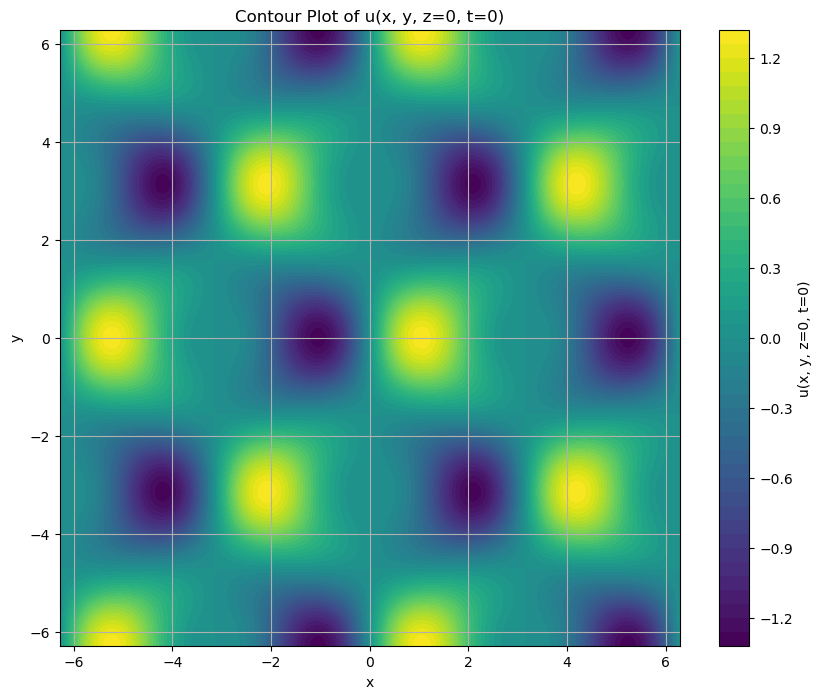

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
t = 0      # Time
z = 0      # Fixed z-coordinate for 2D plotting

# Create a grid of x and y values
x = np.linspace(-2*np.pi, 2*np.pi, 400)
y = np.linspace(-2*np.pi, 2*np.pi, 400)
X, Y = np.meshgrid(x, y)

# Define the velocity components at t=0 and z=0
# Using ** for exponentiation and numpy functions for trigonometry and exponentials
u = (
    (np.cos(X) * (np.cos(Y)**2) * np.sin(X)) -
    (np.cos(X) * np.sin(X) * np.sin(Y) * np.sin(z)) +
    (np.cos(Y) * np.exp(t) * np.sin(X))
) * np.exp(-2*t)

v = (
    (X * Y * z * np.cos(X) * np.cos(z)) +
    (((np.cos(X)**2 - 1) * np.cos(Y) + np.cos(X) * np.exp(t)) * np.sin(z))
) * np.exp(-2*t)

w = (
    (X * z * np.cos(X) * np.sin(z)) +
    ((X**2 * Y**2 - X * Y * np.exp(t) + Y * np.cos(Y) * np.sin(X)) * z)
) * np.exp(-2*t)

# Since z is fixed at 0, v and w will simplify
# For z=0, many terms in v and w become zero
# However, we'll proceed to plot u

# Plotting the u-component
plt.figure(figsize=(10, 8))
contour = plt.contourf(X, Y, u, levels=50, cmap='viridis')
plt.colorbar(contour, label='u(x, y, z=0, t=0)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Contour Plot of u(x, y, z=0, t=0)')
plt.grid(True)
plt.show()

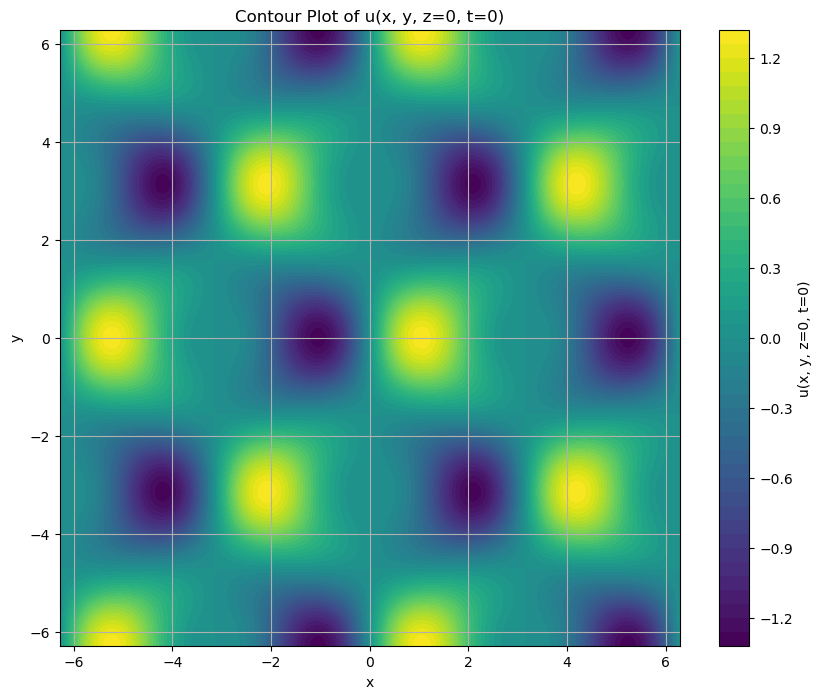

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
t = 0      # Time
z = 0      # Fixed z-coordinate for 2D plotting

# Create a grid of x and y values
x = np.linspace(-2*np.pi, 2*np.pi, 400)
y = np.linspace(-2*np.pi, 2*np.pi, 400)
X, Y = np.meshgrid(x, y)

# Define the velocity components at t=0 and z=0
# Using ** for exponentiation and numpy functions for trigonometry and exponentials
u = (
    (np.cos(X) * (np.cos(Y)**2) * np.sin(X)) -
    (np.cos(X) * np.sin(X) * np.sin(Y) * np.sin(z)) +
    (np.cos(Y) * np.exp(t) * np.sin(X))
) * np.exp(-2*t)

v = (
    (X * Y * z * np.cos(X) * np.cos(z)) +
    (((np.cos(X)**2 - 1) * np.cos(Y) + np.cos(X) * np.exp(t)) * np.sin(z))
) * np.exp(-2*t)

w = (
    (X * z * np.cos(X) * np.sin(z)) +
    ((X**2 * Y**2 - X * Y * np.exp(t) + Y * np.cos(Y) * np.sin(X)) * z)
) * np.exp(-2*t)

# Since z is fixed at 0, v and w will simplify
# For z=0, many terms in v and w become zero
# However, we'll proceed to plot u

# Plotting the u-component
plt.figure(figsize=(10, 8))
contour = plt.contourf(X, Y, u, levels=50, cmap='viridis')
plt.colorbar(contour, label='u(x, y, z=0, t=0)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Contour Plot of u(x, y, z=0, t=0)')
plt.grid(True)
plt.show()

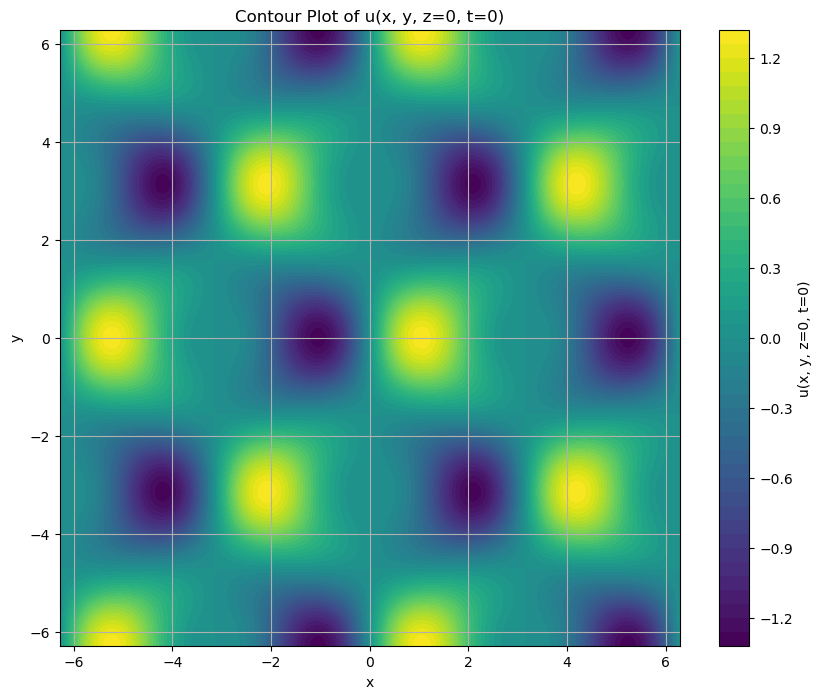

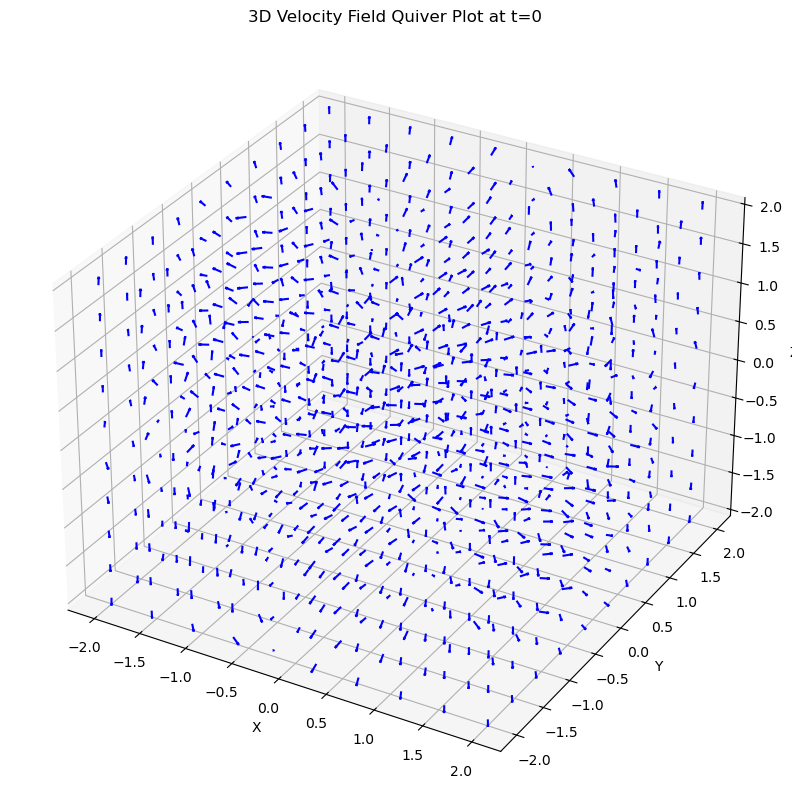

In [42]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
t = 0      # Time is fixed at t = 0 for simplicity
z = 0      # Fix z = 0 for 2D plotting

# Create a grid of x and y values
x = np.linspace(-2*np.pi, 2*np.pi, 400)
y = np.linspace(-2*np.pi, 2*np.pi, 400)
X, Y = np.meshgrid(x, y)

# Define the velocity components at t=0 and z=0 using ** for exponentiation
u = (
    (np.cos(X) * (np.cos(Y)**2) * np.sin(X)) -
    (np.cos(X) * np.sin(X) * np.sin(Y) * np.sin(z)) +
    (np.cos(Y) * np.exp(t) * np.sin(X))
) * np.exp(-2*t)

v = (
    (X * Y * z * np.cos(X) * np.cos(z)) +
    (((np.cos(X)**2 - 1) * np.cos(Y) + np.cos(X) * np.exp(t)) * np.sin(z))
) * np.exp(-2*t)

w = (
    (X * z * np.cos(X) * np.sin(z)) +
    ((X**2 * Y**2 - X * Y * np.exp(t) + Y * np.cos(Y) * np.sin(X)) * z)
) * np.exp(-2*t)

# Since z=0, v and w simplify to zero in this particular 2D case
# However, we'll focus on plotting u

# Plot the u-component
plt.figure(figsize=(10, 8))
contour = plt.contourf(X, Y, u, levels=50, cmap='viridis')
plt.colorbar(contour, label='u(x, y, z=0, t=0)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Contour Plot of u(x, y, z=0, t=0)')
plt.grid(True)
plt.show()

# Optional: If you want to visualize the 3D vector field, use the 3D quiver plot
from mpl_toolkits.mplot3d import Axes3D

# Sample fewer points for a quiver plot to avoid clutter
x_q = np.linspace(-2, 2, 10)
y_q = np.linspace(-2, 2, 10)
z_q = np.linspace(-2, 2, 10)
X_q, Y_q, Z_q = np.meshgrid(x_q, y_q, z_q)

# Compute u, v, w for the 3D quiver plot
u_q = (
    (np.cos(X_q) * (np.cos(Y_q)**2) * np.sin(X_q)) -
    (np.cos(X_q) * np.sin(X_q) * np.sin(Y_q) * np.sin(Z_q)) +
    (np.cos(Y_q) * np.exp(t) * np.sin(X_q))
) * np.exp(-2*t)

v_q = (
    (X_q * Y_q * Z_q * np.cos(X_q) * np.cos(Z_q)) +
    (((np.cos(X_q)**2 - 1) * np.cos(Y_q) + np.cos(X_q) * np.exp(t)) * np.sin(Z_q))
) * np.exp(-2*t)

w_q = (
    (X_q * Z_q * np.cos(X_q) * np.sin(Z_q)) +
    ((X_q**2 * Y_q**2 - X_q * Y_q * np.exp(t) + Y_q * np.cos(Y_q) * np.sin(X_q)) * Z_q)
) * np.exp(-2*t)

# Create 3D quiver plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.quiver(X_q, Y_q, Z_q, u_q, v_q, w_q, length=0.1, normalize=True, color='blue')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Velocity Field Quiver Plot at t=0')
plt.show()

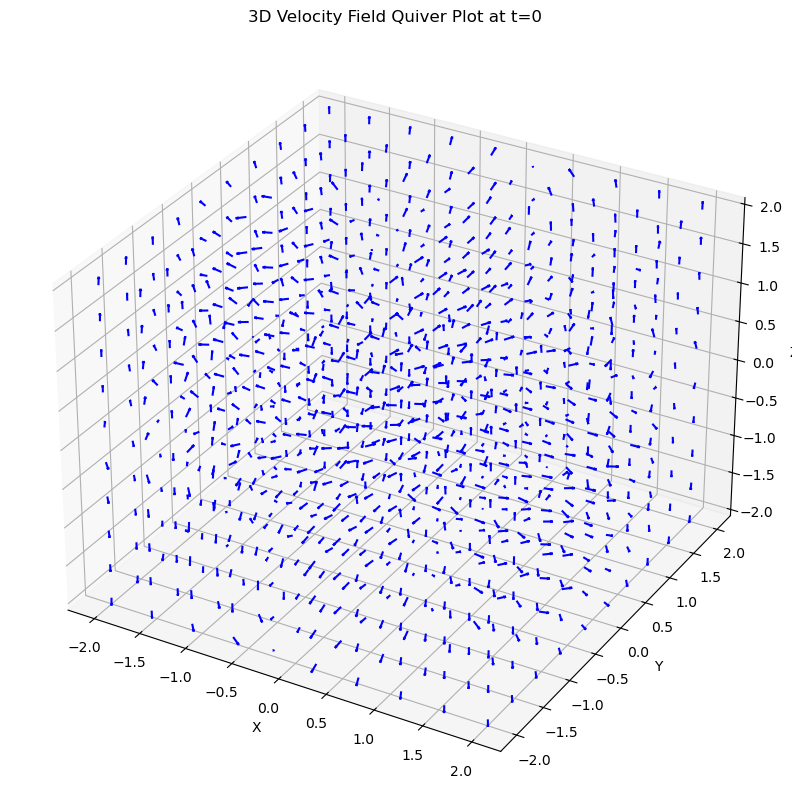

In [43]:
from mpl_toolkits.mplot3d import Axes3D

# For 3D quiver, sample fewer points for clarity
x_q, y_q, z_q = np.linspace(-2, 2, 10), np.linspace(-2, 2, 10), np.linspace(-2, 2, 10)
X_q, Y_q, Z_q = np.meshgrid(x_q, y_q, z_q)

# Compute u, v, w on the quiver grid
u_q = (
    (np.cos(X_q) * (np.cos(Y_q)**2) * np.sin(X_q)) -
    (np.cos(X_q) * np.sin(X_q) * np.sin(Y_q) * np.sin(Z_q)) +
    (np.cos(Y_q) * np.exp(t) * np.sin(X_q))
) * np.exp(-2*t)

v_q = (
    (X_q * Y_q * Z_q * np.cos(X_q) * np.cos(Z_q)) +
    (((np.cos(X_q)**2 - 1) * np.cos(Y_q) + np.cos(X_q) * np.exp(t)) * np.sin(Z_q))
) * np.exp(-2*t)

w_q = (
    (X_q * Z_q * np.cos(X_q) * np.sin(Z_q)) +
    ((X_q**2 * Y_q**2 - X_q * Y_q * np.exp(t) + Y_q * np.cos(Y_q) * np.sin(X_q)) * Z_q)
) * np.exp(-2*t)

# Create 3D quiver plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.quiver(X_q, Y_q, Z_q, u_q, v_q, w_q, length=0.1, normalize=True, color='blue')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Velocity Field Quiver Plot at t=0')
plt.show()


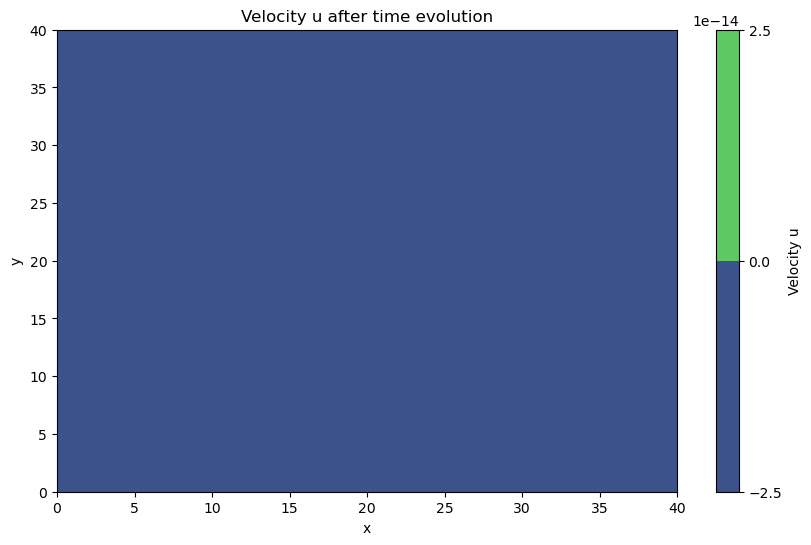

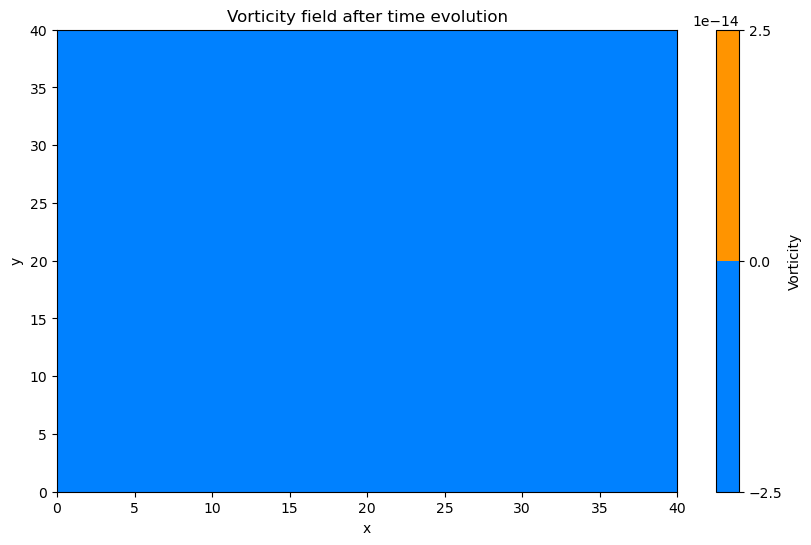

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Define grid size
nx, ny = 41, 41  # Number of grid points in x and y direction
nt = 500  # Number of time steps
dx = 2 / (nx - 1)  # Grid spacing in x-direction
dy = 2 / (ny - 1)  # Grid spacing in y-direction
dt = 0.001  # Time step

# Define physical parameters
rho = 1  # Fluid density
nu = 0.1  # Kinematic viscosity (modify as needed)

# Initialize velocity and pressure fields
u = np.zeros((ny, nx))  # u-component of velocity
v = np.zeros((ny, nx))  # v-component of velocity
p = np.zeros((ny, nx))  # Pressure field

# Boundary conditions (no-slip at walls)
def boundary_conditions(u, v):
    u[0, :] = 0  # Top wall (no-slip)
    u[-1, :] = 0  # Bottom wall (no-slip)
    u[:, 0] = 0  # Left wall (no-slip)
    u[:, -1] = 0  # Right wall (no-slip)
    
    v[0, :] = 0  # Top wall
    v[-1, :] = 0  # Bottom wall
    v[:, 0] = 0  # Left wall
    v[:, -1] = 0  # Right wall

# Compute vorticity (rotation in the flow)
def vorticity(u, v, dx, dy):
    return (np.gradient(v, dx, axis=1) - np.gradient(u, dy, axis=0))

# Numerical solution of the Navier-Stokes equations using FDM
def navier_stokes(u, v, p, dt, dx, dy, rho, nu):
    un = u.copy()
    vn = v.copy()

    # Compute intermediate values for velocity components
    u[1:-1, 1:-1] = (un[1:-1, 1:-1] -
                     dt / dx * un[1:-1, 1:-1] * (un[1:-1, 1:-1] - un[1:-1, :-2]) -
                     dt / dy * vn[1:-1, 1:-1] * (un[1:-1, 1:-1] - un[:-2, 1:-1]) +
                     nu * dt / dx**2 * (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, :-2]) +
                     nu * dt / dy**2 * (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[:-2, 1:-1]))

    v[1:-1, 1:-1] = (vn[1:-1, 1:-1] -
                     dt / dx * un[1:-1, 1:-1] * (vn[1:-1, 1:-1] - vn[1:-1, :-2]) -
                     dt / dy * vn[1:-1, 1:-1] * (vn[1:-1, 1:-1] - vn[:-2, 1:-1]) +
                     nu * dt / dx**2 * (vn[1:-1, 2:] - 2 * vn[1:-1, 1:-1] + vn[1:-1, :-2]) +
                     nu * dt / dy**2 * (vn[2:, 1:-1] - 2 * vn[1:-1, 1:-1] + vn[:-2, 1:-1]))

    return u, v

# Time-stepping loop
for n in range(nt):
    u, v = navier_stokes(u, v, p, dt, dx, dy, rho, nu)
    boundary_conditions(u, v)

# Visualize the velocity field after time evolution
plt.figure(figsize=(10, 6))
plt.contourf(u.T, cmap="viridis")
plt.colorbar(label="Velocity u")
plt.title("Velocity u after time evolution")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Compute and visualize vorticity
vort = vorticity(u, v, dx, dy)
plt.figure(figsize=(10, 6))
plt.contourf(vort.T, cmap="jet")
plt.colorbar(label="Vorticity")
plt.title("Vorticity field after time evolution")
plt.xlabel('x')
plt.ylabel('y')
plt.show()


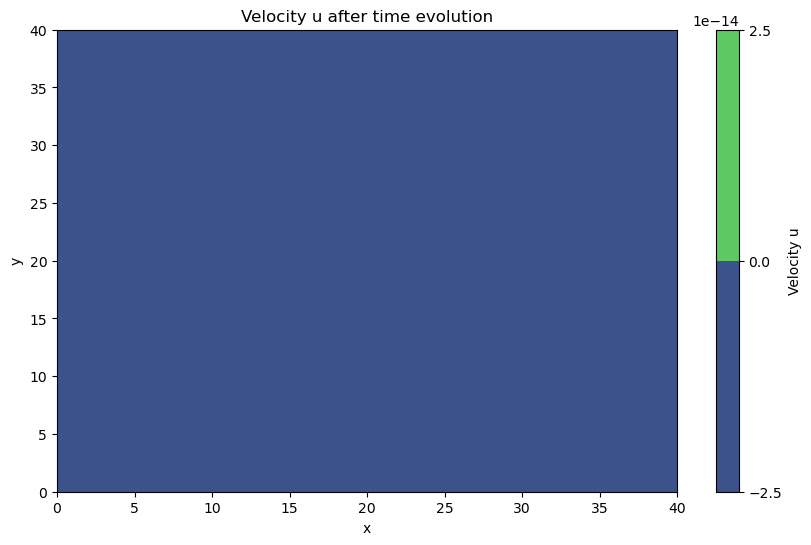

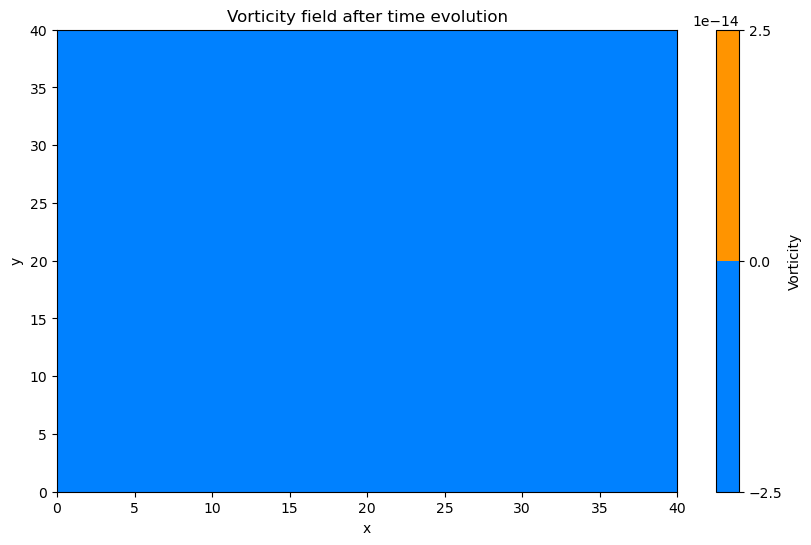

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Define grid size
nx, ny = 41, 41  # Number of grid points in x and y direction
nt = 500  # Number of time steps
dx = 2 / (nx - 1)  # Grid spacing in x-direction
dy = 2 / (ny - 1)  # Grid spacing in y-direction
dt = 0.001  # Time step

# Define physical parameters
rho = 1  # Fluid density
nu = 0.1  # Kinematic viscosity (modify as needed)

# Initialize velocity and pressure fields
u = np.zeros((ny, nx))  # u-component of velocity
v = np.zeros((ny, nx))  # v-component of velocity
p = np.zeros((ny, nx))  # Pressure field

# Boundary conditions (no-slip at walls)
def boundary_conditions(u, v):
    u[0, :] = 0  # Top wall (no-slip)
    u[-1, :] = 0  # Bottom wall (no-slip)
    u[:, 0] = 0  # Left wall (no-slip)
    u[:, -1] = 0  # Right wall (no-slip)
    
    v[0, :] = 0  # Top wall
    v[-1, :] = 0  # Bottom wall
    v[:, 0] = 0  # Left wall
    v[:, -1] = 0  # Right wall

# Compute vorticity (rotation in the flow)
def vorticity(u, v, dx, dy):
    return (np.gradient(v, dx, axis=1) - np.gradient(u, dy, axis=0))

# Numerical solution of the Navier-Stokes equations using FDM
def navier_stokes(u, v, p, dt, dx, dy, rho, nu):
    un = u.copy()
    vn = v.copy()

    # Compute intermediate values for velocity components
    u[1:-1, 1:-1] = (un[1:-1, 1:-1] -
                     dt / dx * un[1:-1, 1:-1] * (un[1:-1, 1:-1] - un[1:-1, :-2]) -
                     dt / dy * vn[1:-1, 1:-1] * (un[1:-1, 1:-1] - un[:-2, 1:-1]) +
                     nu * dt / dx**2 * (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, :-2]) +
                     nu * dt / dy**2 * (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[:-2, 1:-1]))

    v[1:-1, 1:-1] = (vn[1:-1, 1:-1] -
                     dt / dx * un[1:-1, 1:-1] * (vn[1:-1, 1:-1] - vn[1:-1, :-2]) -
                     dt / dy * vn[1:-1, 1:-1] * (vn[1:-1, 1:-1] - vn[:-2, 1:-1]) +
                     nu * dt / dx**2 * (vn[1:-1, 2:] - 2 * vn[1:-1, 1:-1] + vn[1:-1, :-2]) +
                     nu * dt / dy**2 * (vn[2:, 1:-1] - 2 * vn[1:-1, 1:-1] + vn[:-2, 1:-1]))

    return u, v

# Time-stepping loop
for n in range(nt):
    u, v = navier_stokes(u, v, p, dt, dx, dy, rho, nu)
    boundary_conditions(u, v)

# Visualize the velocity field after time evolution
plt.figure(figsize=(10, 6))
plt.contourf(u.T, cmap="viridis")
plt.colorbar(label="Velocity u")
plt.title("Velocity u after time evolution")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Compute and visualize vorticity
vort = vorticity(u, v, dx, dy)
plt.figure(figsize=(10, 6))
plt.contourf(vort.T, cmap="jet")
plt.colorbar(label="Vorticity")
plt.title("Vorticity field after time evolution")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

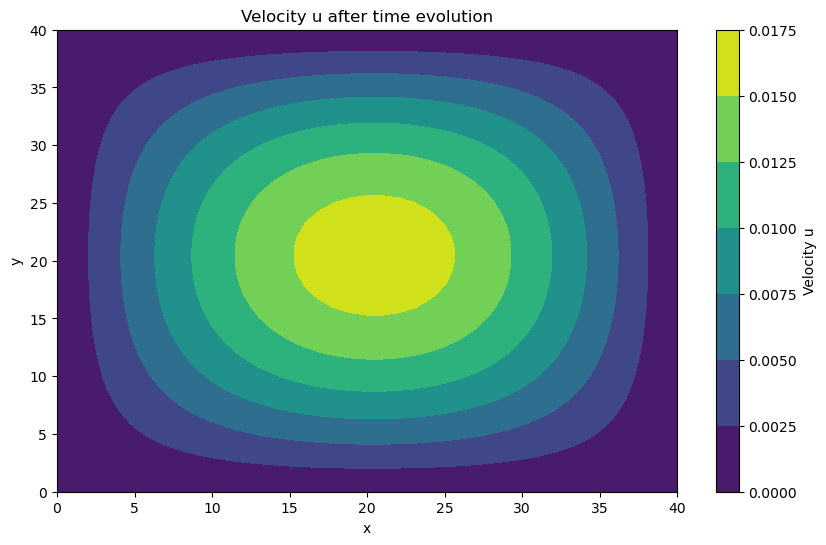

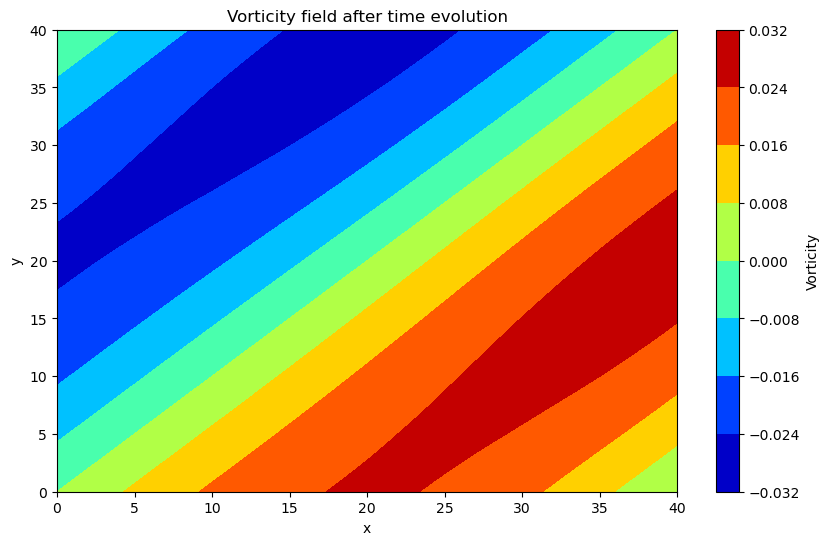

In [46]:
# Refined parameters
nu = 0.1  # Adjusted viscosity
dt = 0.005  # Slightly larger time step
nt = 1000  # More time steps to evolve further

# Adjust initial conditions or boundary conditions to induce flow
u[10:20, 10:20] = 1.0  # Example: Set an initial velocity in a small region to induce flow
v[10:20, 10:20] = 1.0

# Time-stepping loop
for n in range(nt):
    u, v = navier_stokes(u, v, p, dt, dx, dy, rho, nu)
    boundary_conditions(u, v)

# Recompute and visualize the velocity and vorticity fields
plt.figure(figsize=(10, 6))
plt.contourf(u.T, cmap="viridis")
plt.colorbar(label="Velocity u")
plt.title("Velocity u after time evolution")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

vort = vorticity(u, v, dx, dy)
plt.figure(figsize=(10, 6))
plt.contourf(vort.T, cmap="jet")
plt.colorbar(label="Vorticity")
plt.title("Vorticity field after time evolution")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Define grid size
nx, ny = 41, 41  # Number of grid points in x and y direction
x = np.linspace(0, 2*np.pi, nx)
y = np.linspace(0, 2*np.pi, ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y)

# Define time-stepping parameters
dt = 0.01  # Time step size
nt = 500   # Number of time steps

# Viscosity parameter (nu)
nu = 0.1

# Initialize velocity fields u and v (initially set to zero)
u = np.zeros((nx, ny))
v = np.zeros((nx, ny))

# Introduce perturbations for initial velocity in a small region
u[10:20, 10:20] = 1.0
v[10:20, 10:20] = 1.0

# Define boundary conditions (periodic boundaries)
def apply_boundary_conditions(u, v):
    u[0, :] = u[-1, :]
    u[:, 0] = u[:, -1]
    v[0, :] = v[-1, :]
    v[:, 0] = v[:, -1]
    return u, v

# Time-stepping loop for velocity update
for n in range(nt):
    un = u.copy()
    vn = v.copy()
    
    # Compute derivatives using central differences
    dudx = (un[1:, :] - un[:-1, :]) / dx
    dudy = (un[:, 1:] - un[:, :-1]) / dy
    dvdx = (vn[1:, :] - vn[:-1, :]) / dx
    dvdy = (vn[:, 1:] - vn[:, :-1]) / dy
    
    # Update velocities using the finite difference method (FDM)
    u[1:-1, 1:-1] = (un[1:-1, 1:-1] -
                     dt * (un[1:-1, 1:-1] * dudx[1:, :] +
                           vn[1:-1, 1:-1] * dudy[:, 1:]) +
                     nu * (dudx[1:, :] + dudy[:, 1:]) * dt)

    v[1:-1, 1:-1] = (vn[1:-1, 1:-1] -
                     dt * (un[1:-1, 1:-1] * dvdx[1:, :] +
                           vn[1:-1, 1:-1] * dvdy[:, 1:]) +
                     nu * (dvdx[1:, :] + dvdy[:, 1:]) * dt)
    
    # Apply periodic boundary conditions
    u, v = apply_boundary_conditions(u, v)

# Calculate vorticity as the curl of the velocity field
vort = (np.gradient(v, dx, axis=1) - np.gradient(u, dy, axis=0))

# Plot velocity field and vorticity
plt.figure(figsize=(12, 6))

# Plot u velocity component
plt.subplot(1, 2, 1)
plt.contourf(X, Y, u, levels=50, cmap='viridis')
plt.colorbar(label="Velocity u")
plt.title("Velocity u after time evolution")
plt.xlabel('x')
plt.ylabel('y')

# Plot vorticity field
plt.subplot(1, 2, 2)
plt.contourf(X, Y, vort, levels=50, cmap='jet')
plt.colorbar(label="Vorticity")
plt.title("Vorticity field after time evolution")
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.show()

ValueError: operands could not be broadcast together with shapes (39,39) (39,41) 